# Multiple-objective portfolio optimization

 Weight's Order:
 
 - 1 SuperFuture
 - 2 Apples
 - 3 WorldNow
 - 4 Electronics123
 - 5 Photons
 - 6 SpaceNow
 - 7 PearPear
 - 8 PositiveCorrelation
 - 9 BetterTechnology
 - 10 ABCDE
 - 11 EnviroLike
 - 12 Moneymakers
 - 13 Fuel4
 - 14 MarsProject
 - 15 CPU-XYZ
 - 16 RoboticsX
 - 17 Lasers
 - 18 WaterForce
 - 19 SafeAndCare
 - 20 BetterTomorrow

## Imports

In [1]:
from utils.MOO_utilities import *

In [2]:
### SOLVE HERE

ORDER = ["SuperFuture", "Apples", "WorldNow", "Electronics123", "Photons", "SpaceNow", "PearPear",
         "PositiveCorrelation", "BetterTechnology", "ABCDE", "EnviroLike", "Moneymakers", "Fuel4",
         "MarsProject", "CPU-XYZ", "RoboticsX", "Lasers", "WaterForce", "SafeAndCare", "BetterTomorrow"]

## Data

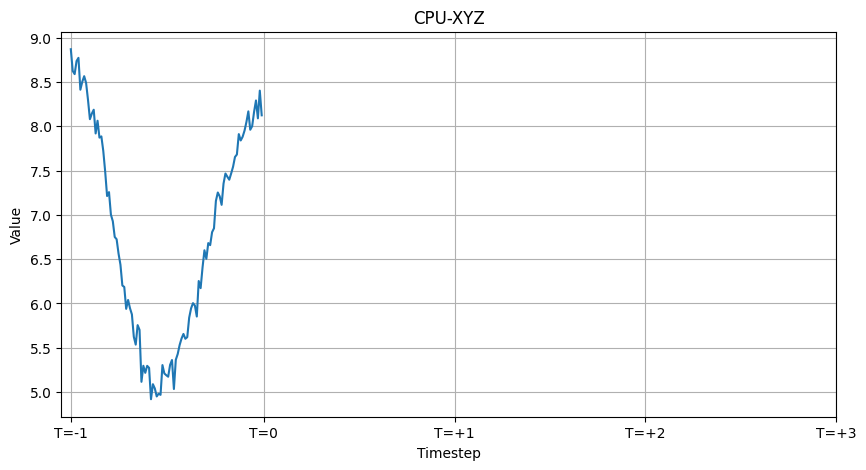

In [3]:
dr = DataReader("./data/Bundle1")
dr.read_data()
dr.plot()
data = dr.get_data()
assert len(data.keys()) == 20

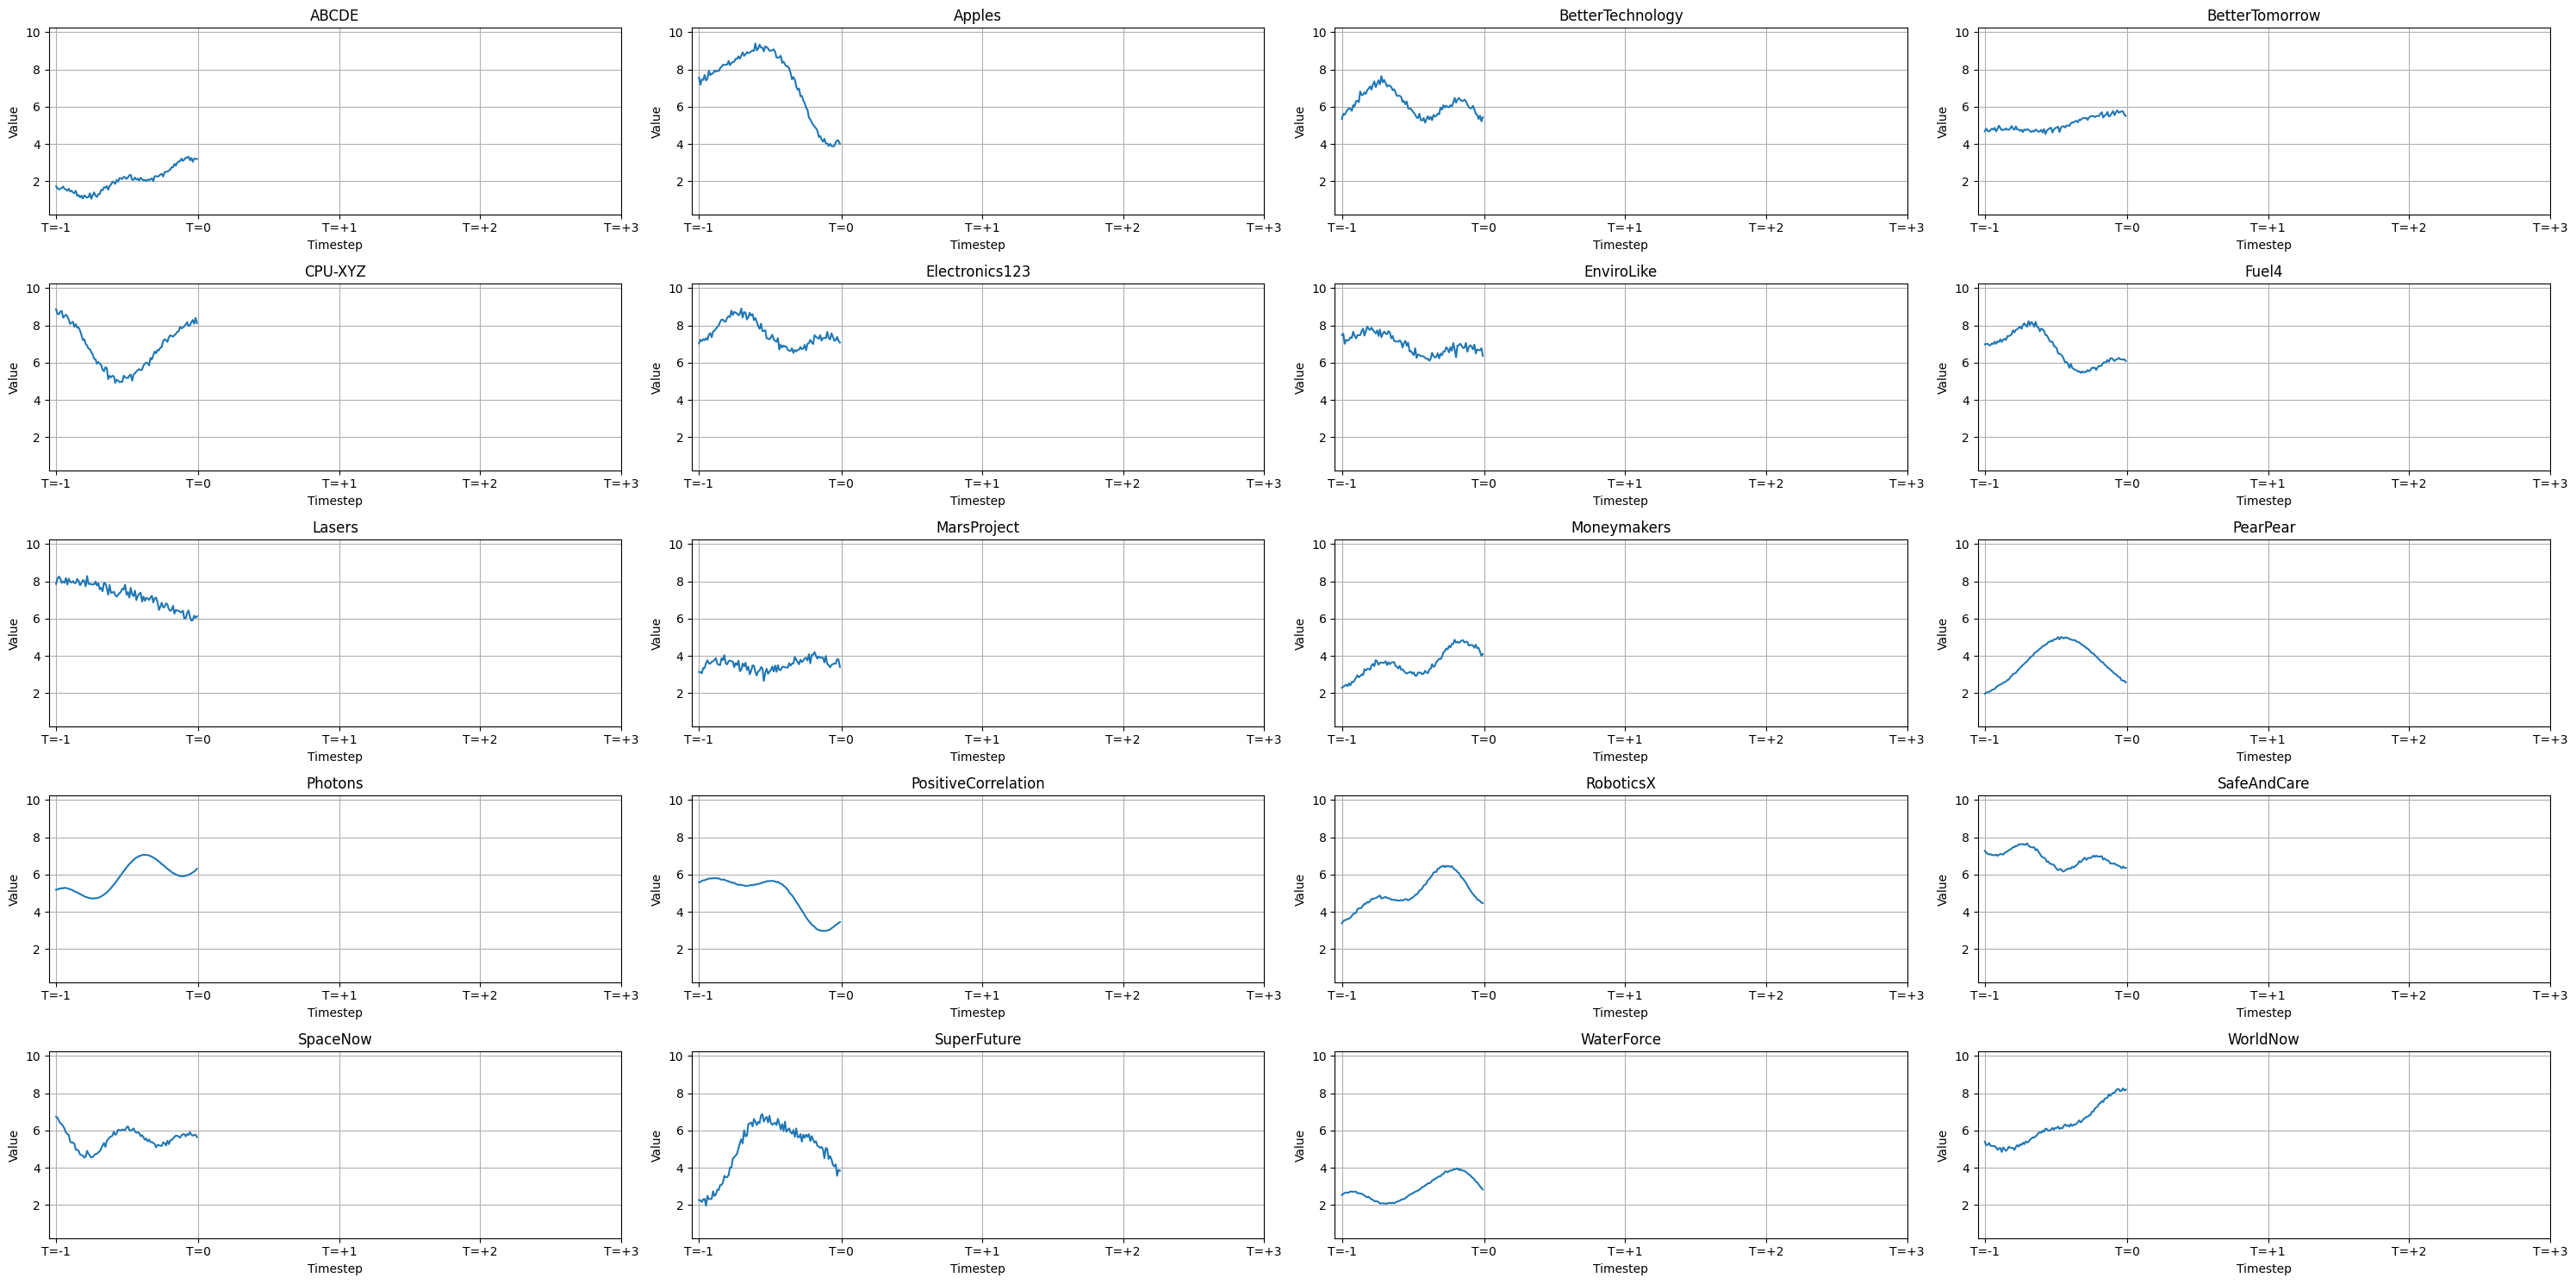

In [4]:
dr.plot_all(figsize=(30, 15), normalized_y=True)

## Regression Algorithms

### Linear Regression

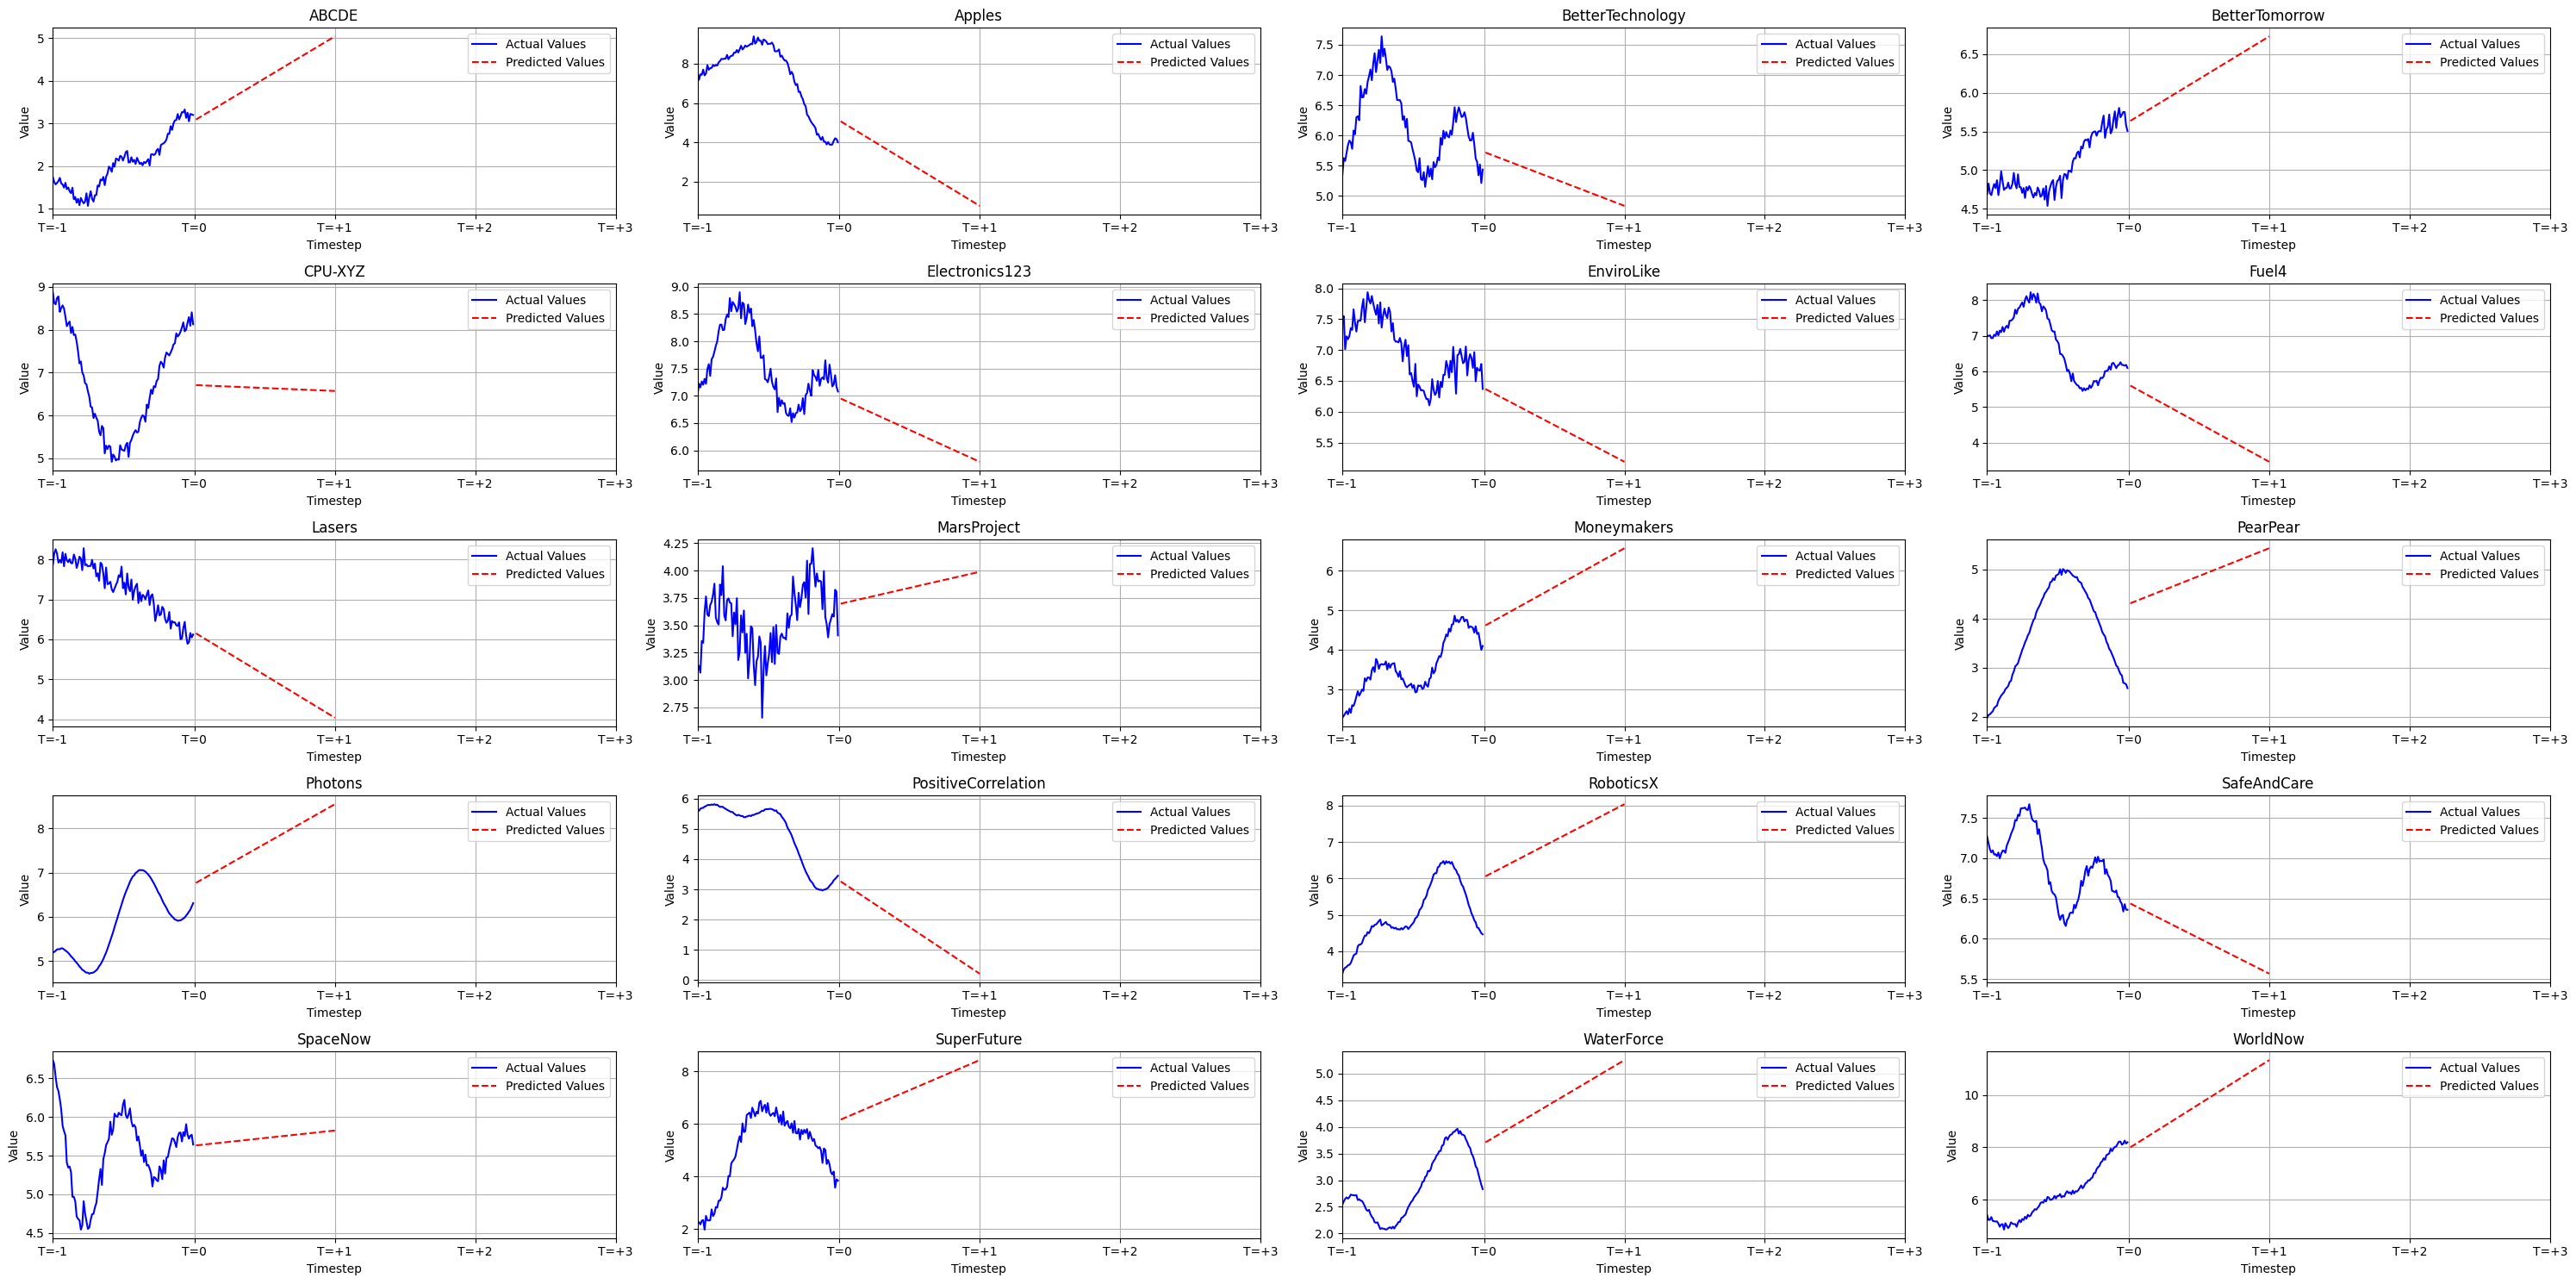

In [5]:
RMC = RegressionModelsCombined(data)
RMC.create_X_y(101)
RMC.train_linear()
linear_predictions = RMC.predict_linear()
RMC.plot_predictions(val_range=201, predictions=linear_predictions, figsize=(30, 15))

### Sinusoidal Regression

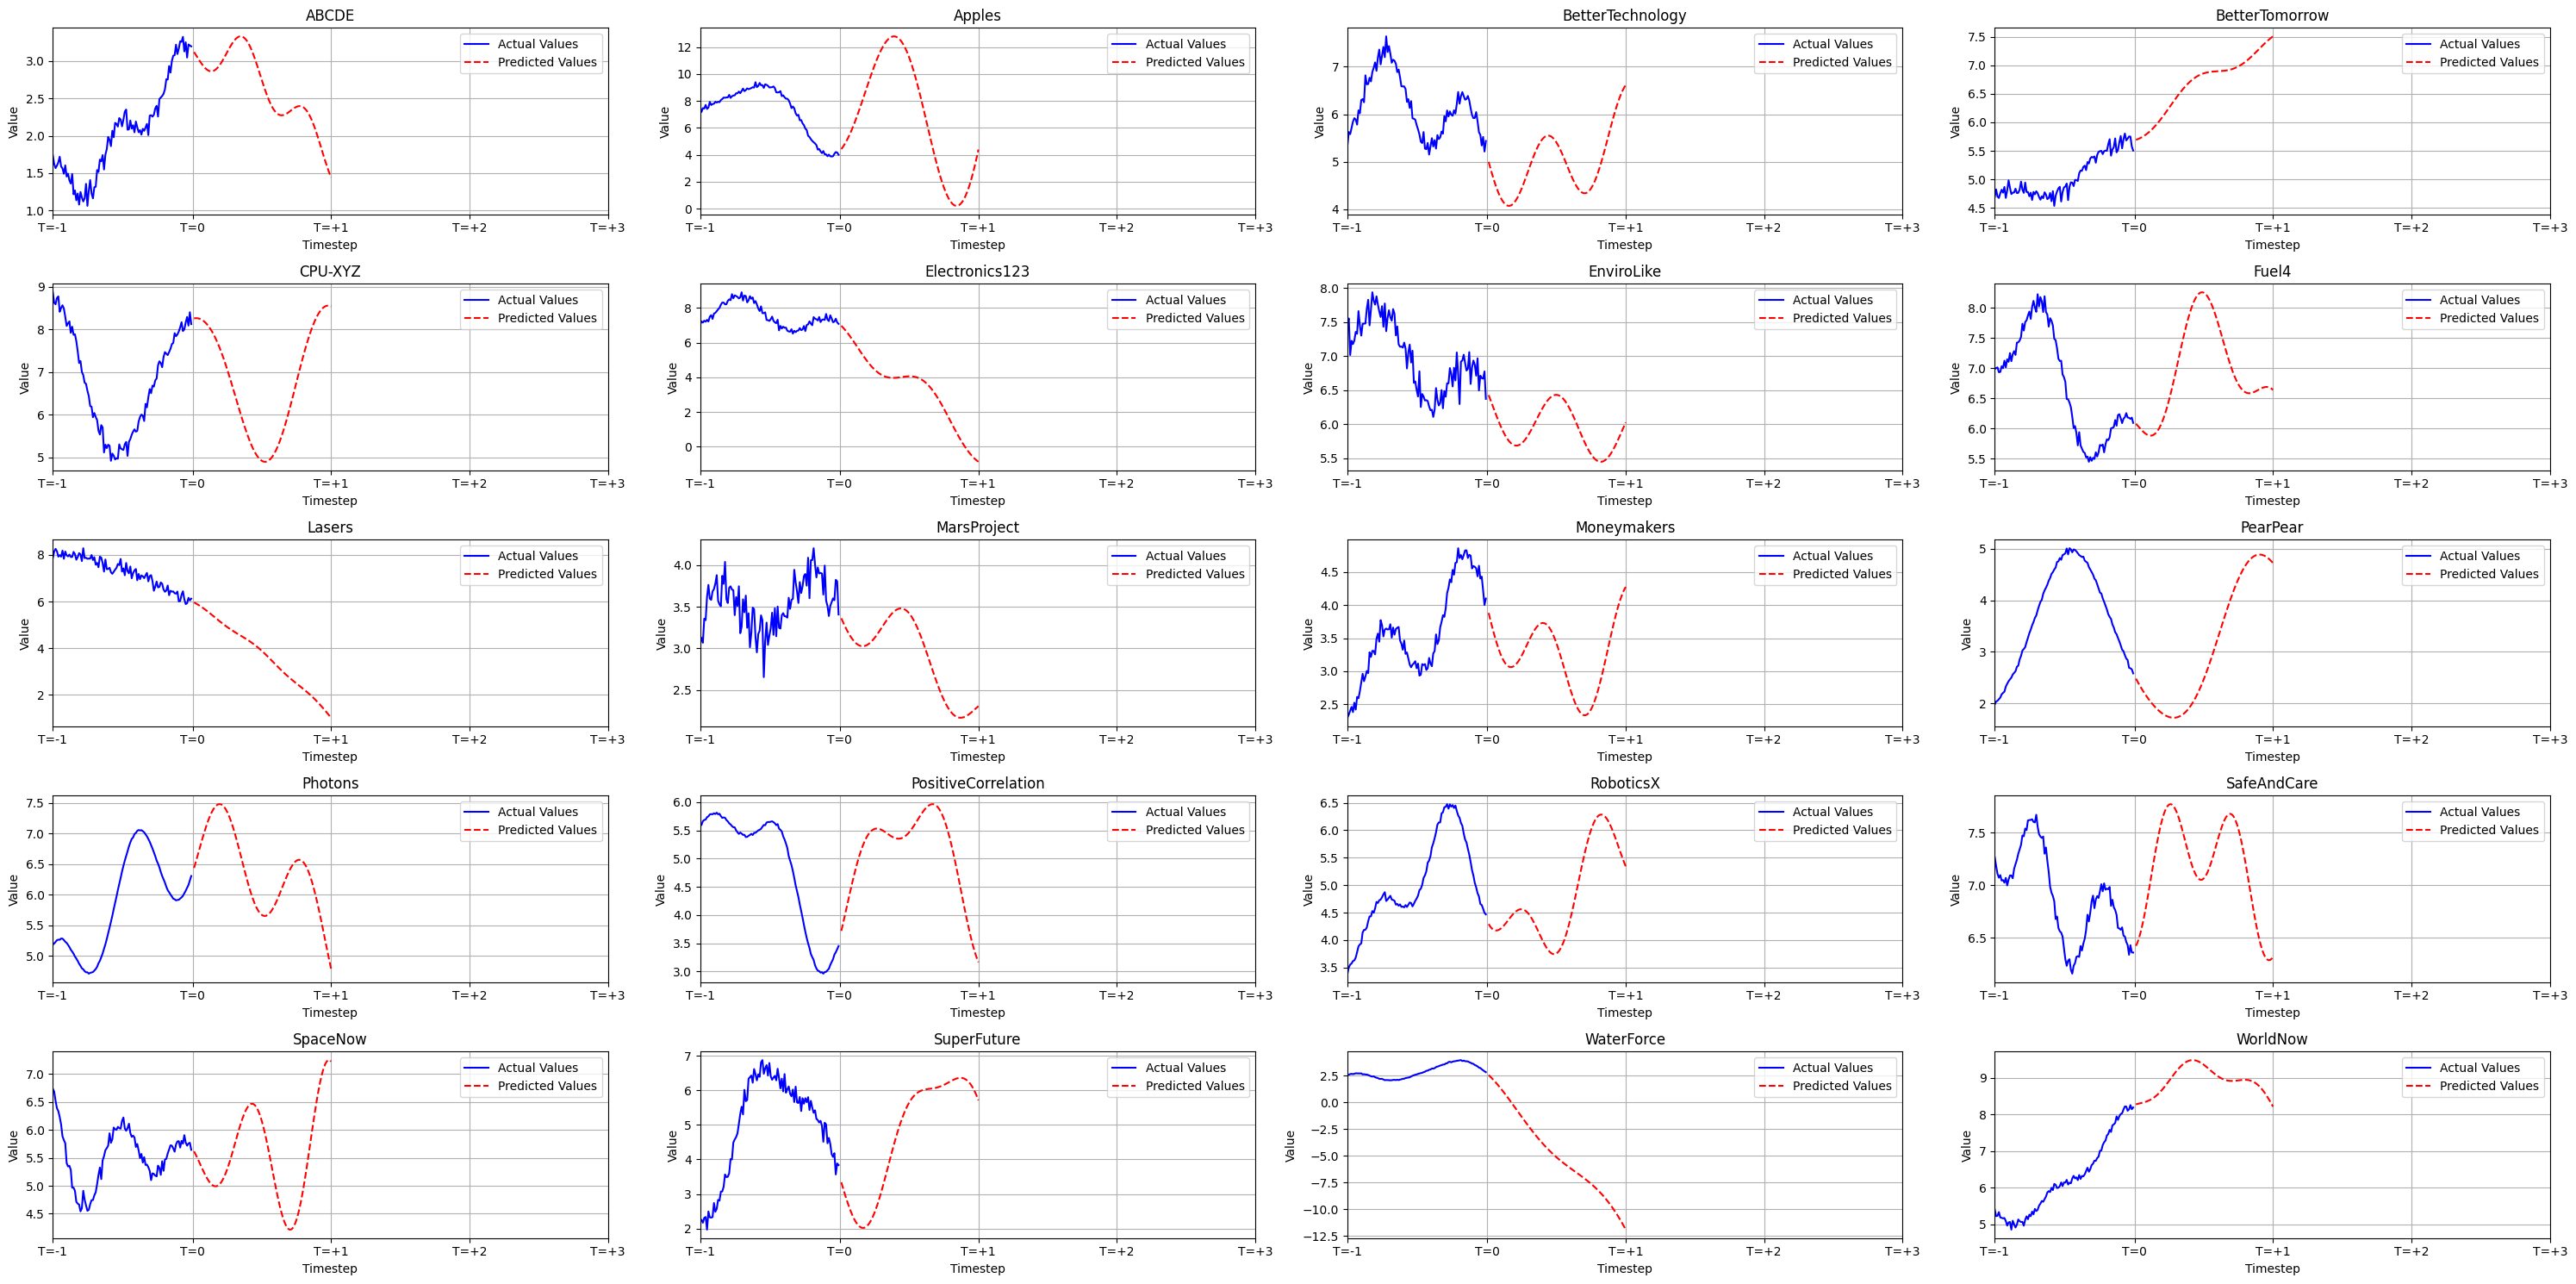

In [6]:
RMC = RegressionModelsCombined(data)
RMC.create_X_y(101)
RMC.train_sinusoidal()
sinusoidal_predictions = RMC.predict_sinusoidal()
RMC.plot_predictions(val_range=201, predictions=sinusoidal_predictions, figsize=(30, 15))

### Sinusoidal + Linear Regression

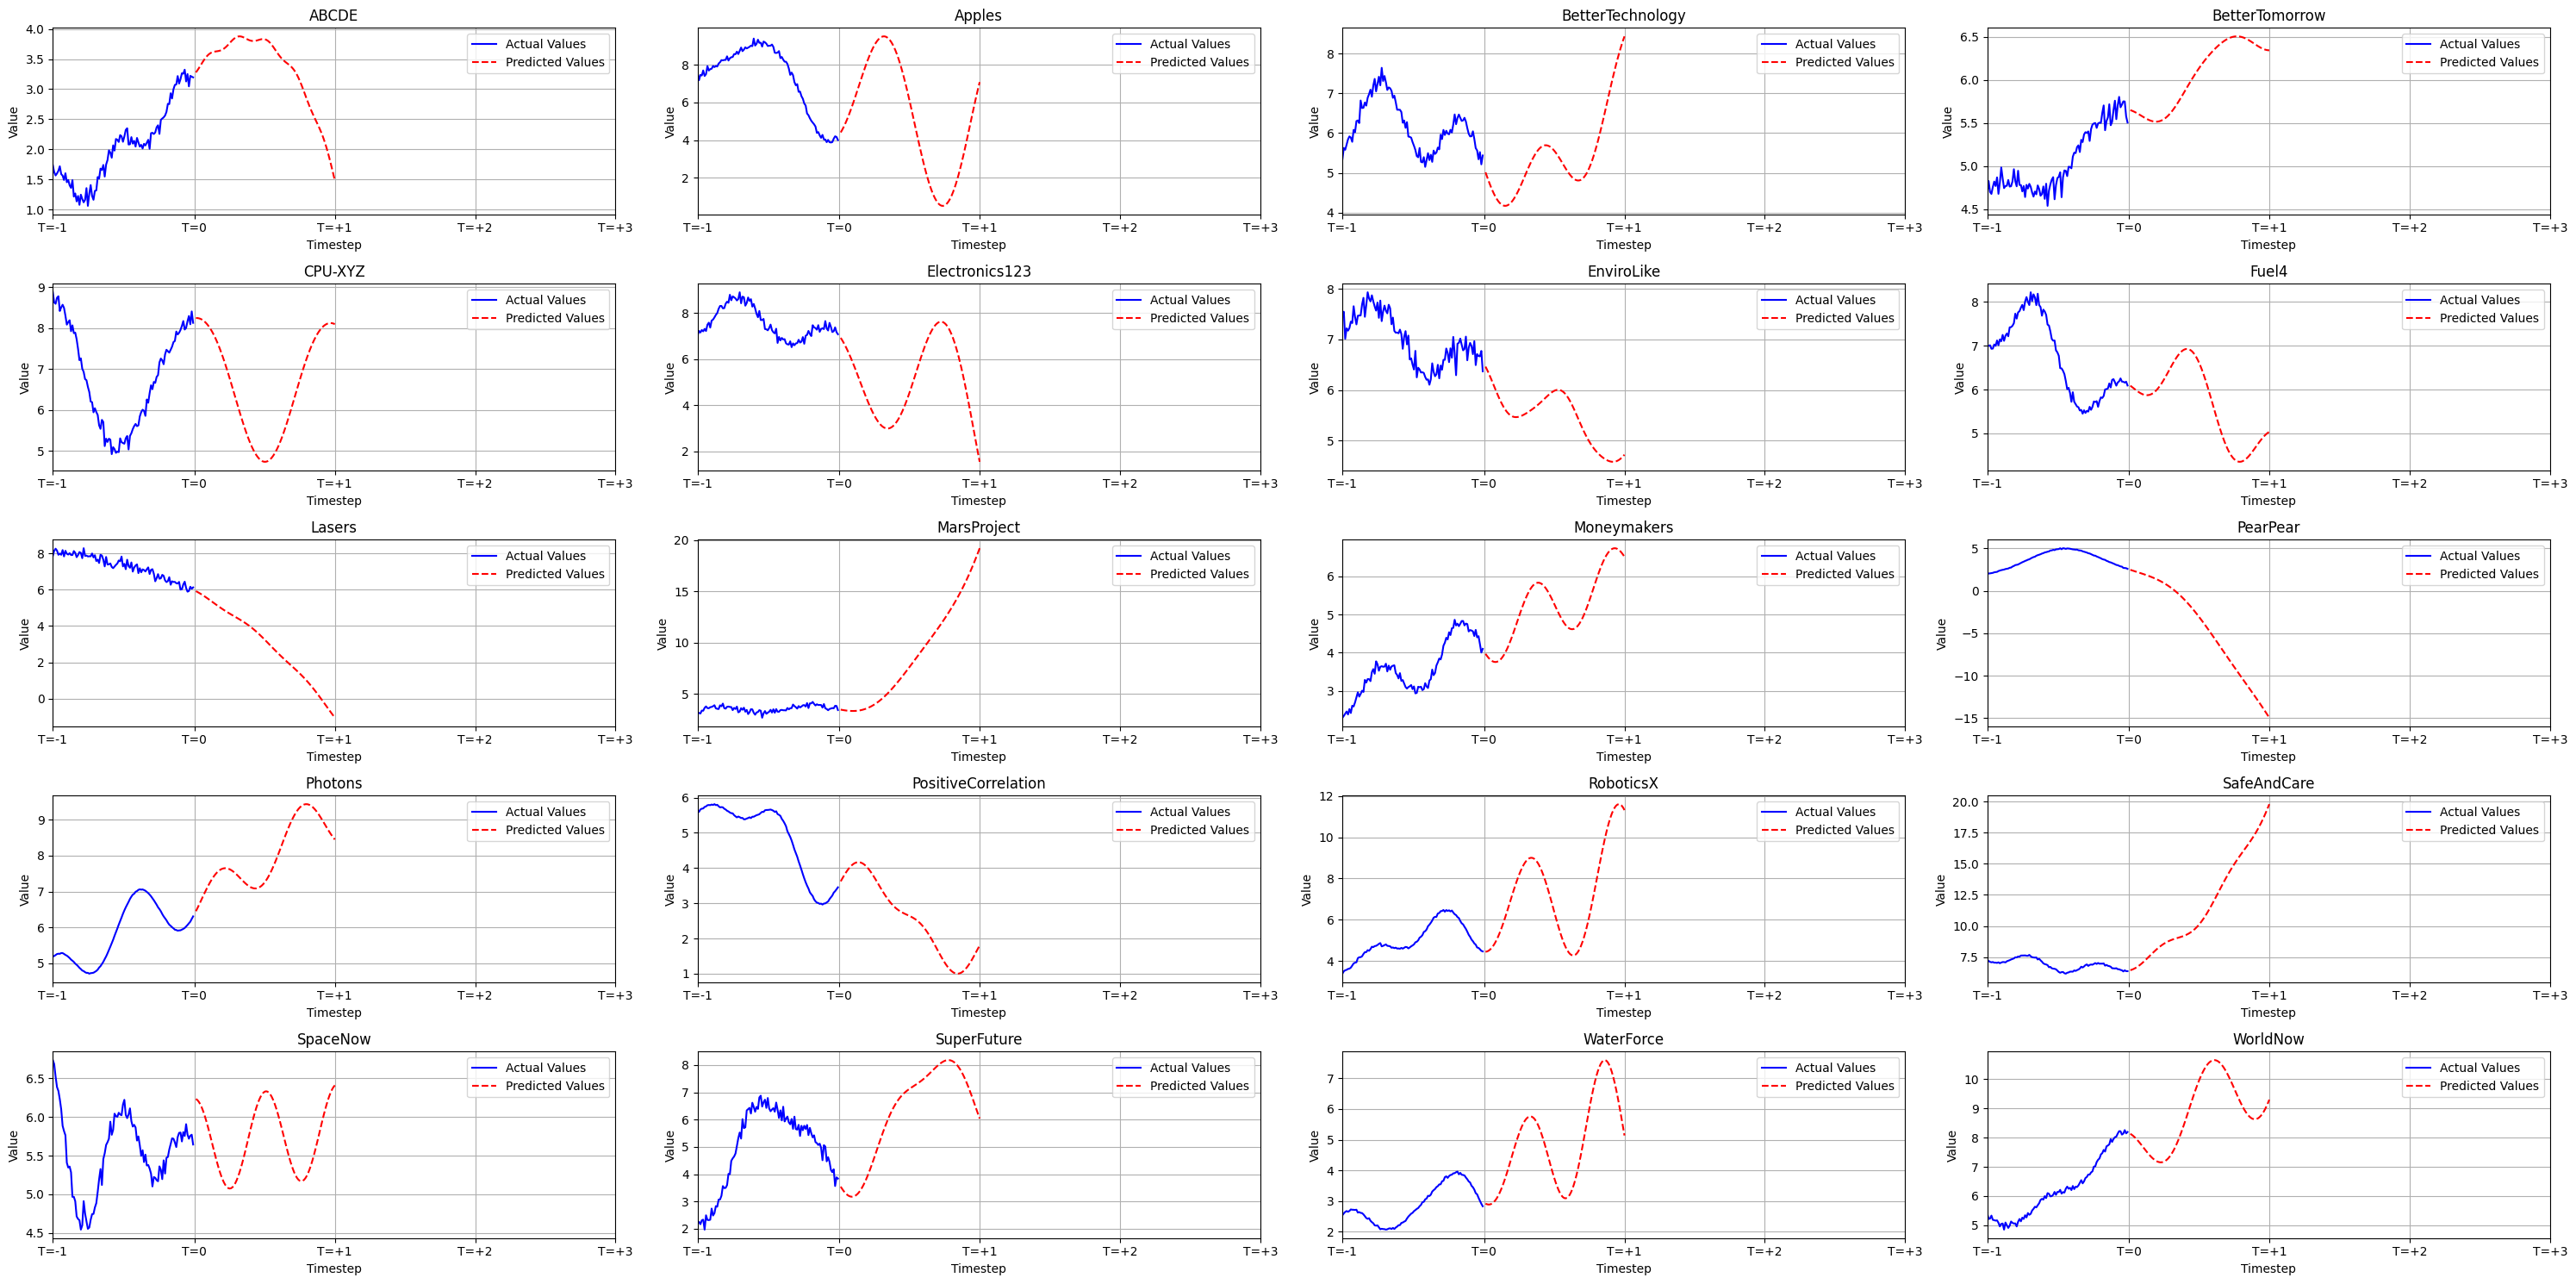

In [7]:
RMC = RegressionModelsCombined(data)
RMC.create_X_y(101)
RMC.train_complex_sinusoidal()
complex_sinusoidal_predictions = RMC.predict_complex_sinusoidal()
RMC.plot_predictions(val_range=201, predictions=complex_sinusoidal_predictions, figsize=(30, 15))

## ARIMA

Lags for company = ABCDE


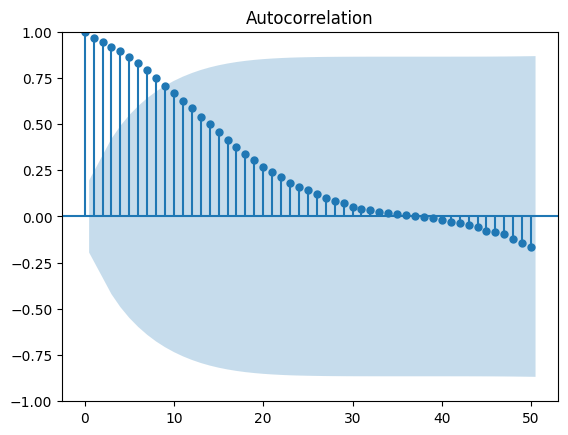

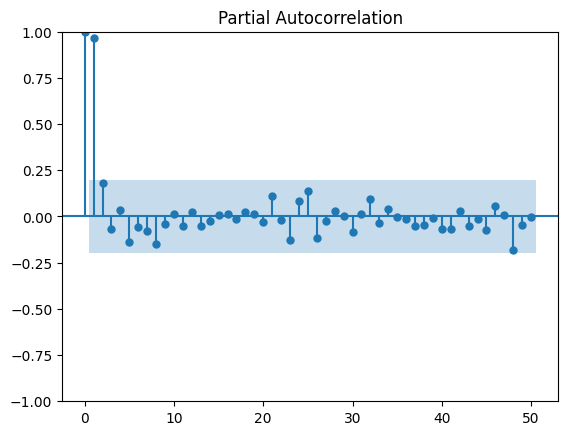

Lags for company = Apples


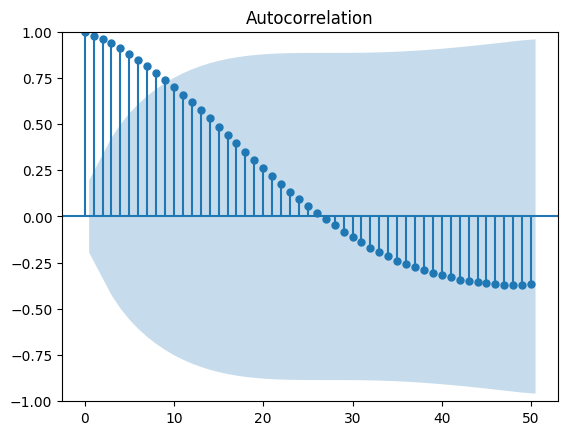

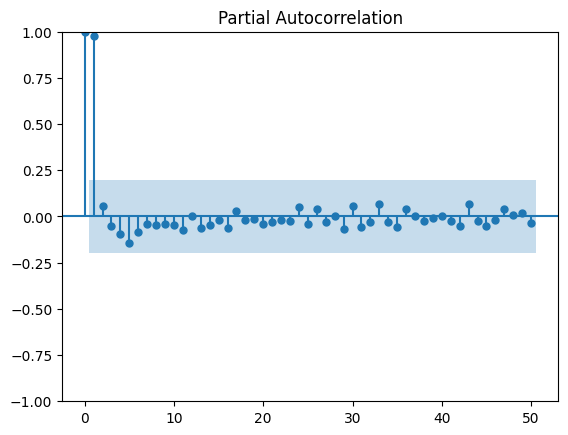

Lags for company = BetterTechnology


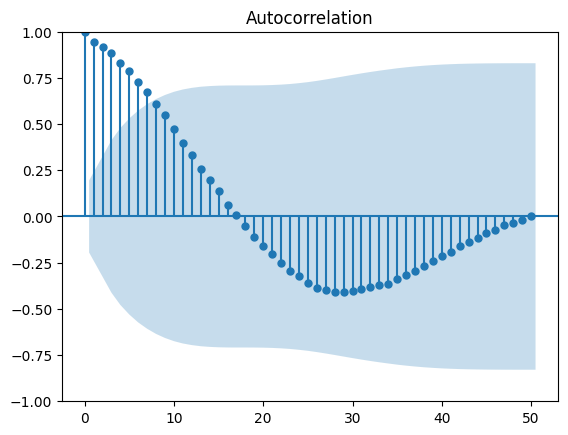

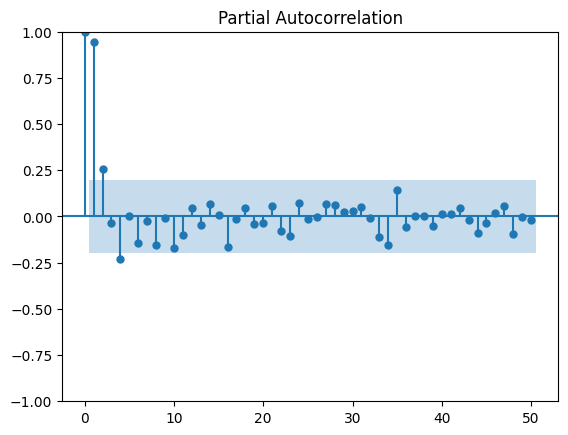

Lags for company = BetterTomorrow


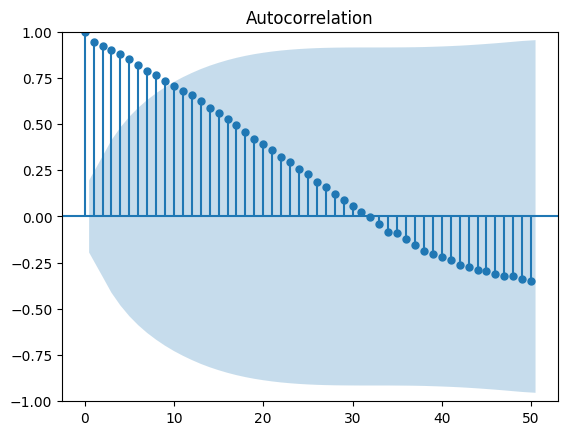

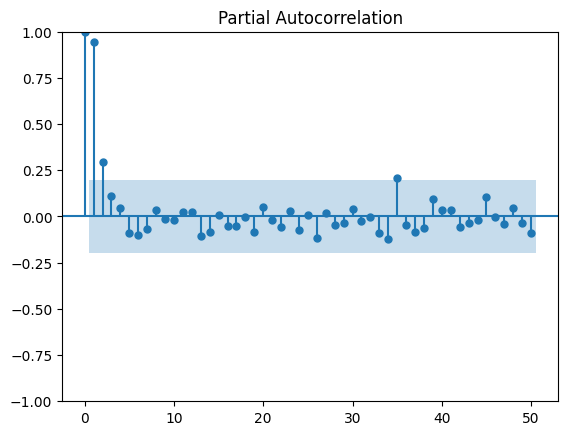

Lags for company = CPU-XYZ


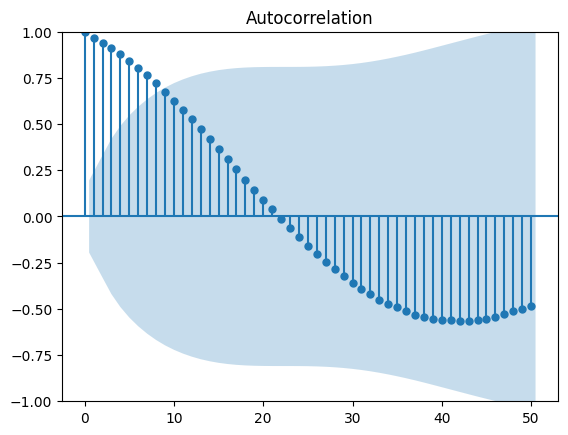

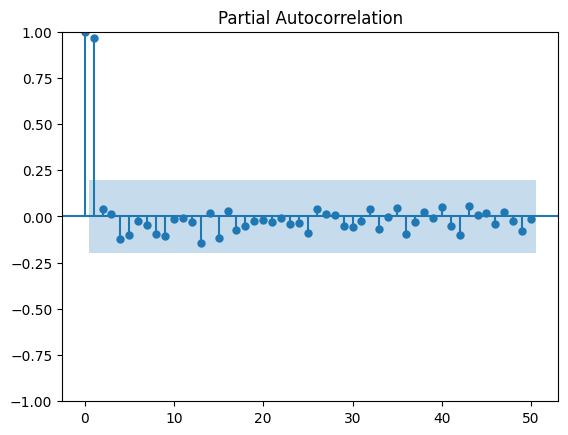

Lags for company = Electronics123


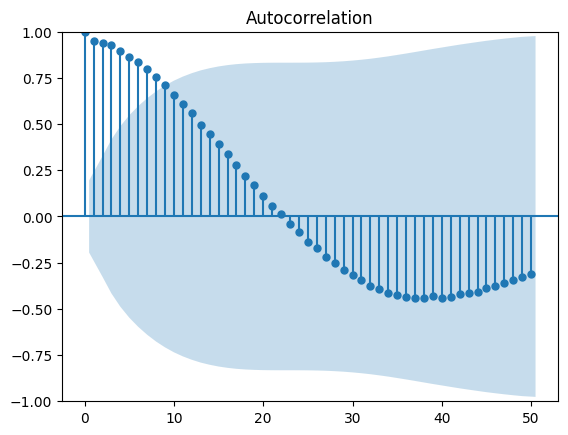

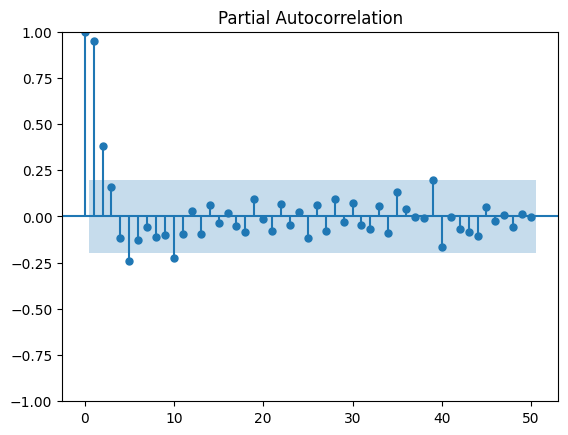

Lags for company = EnviroLike


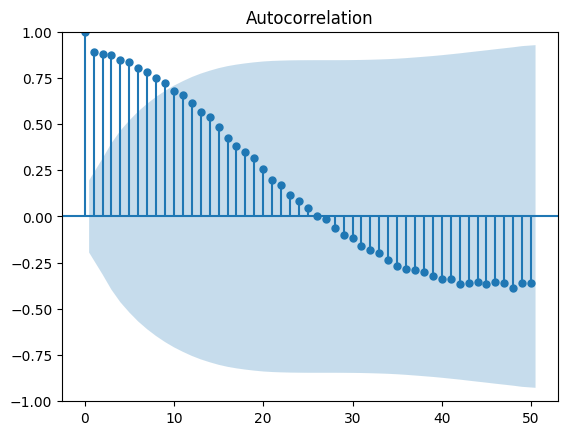

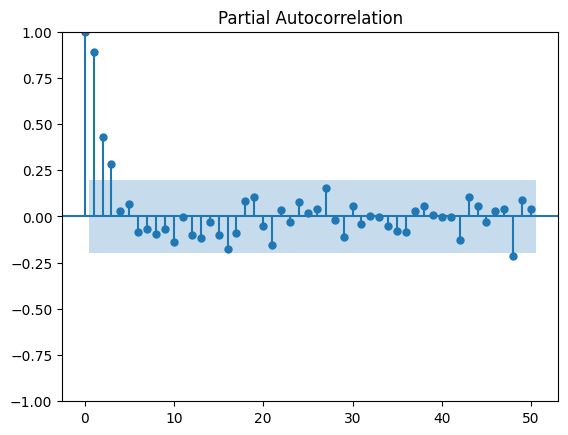

Lags for company = Fuel4


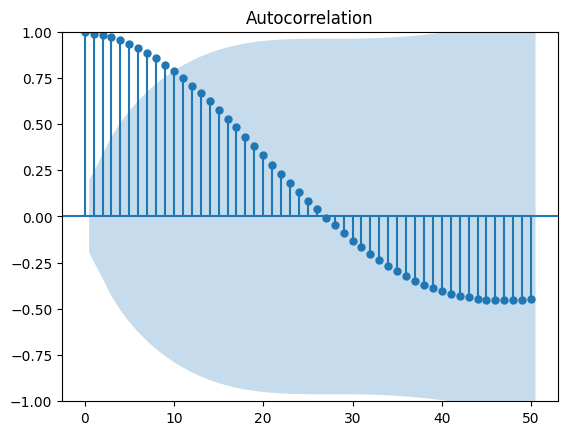

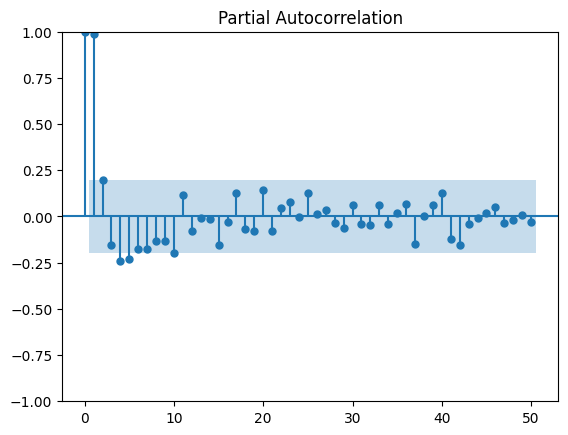

Lags for company = Lasers


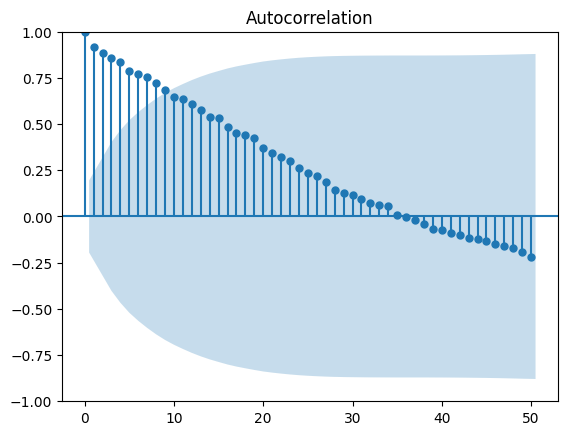

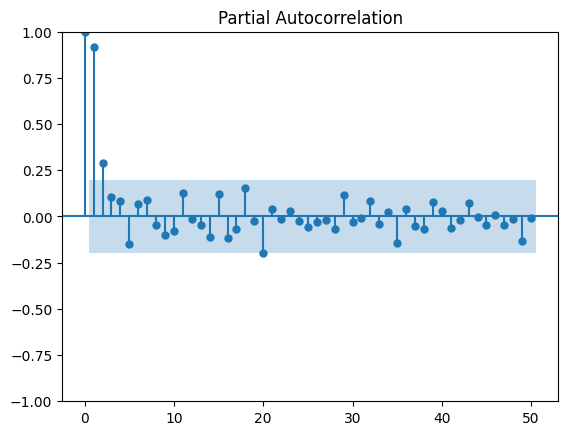

Lags for company = MarsProject


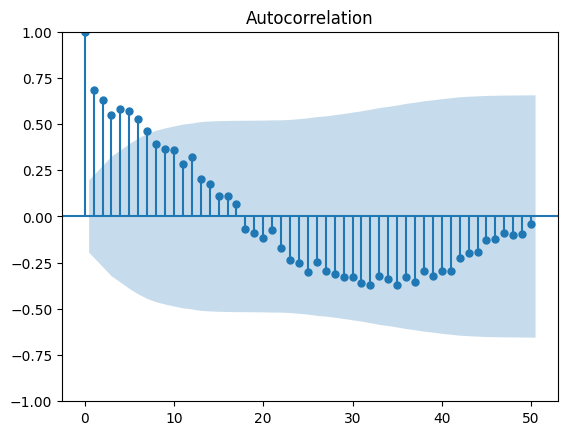

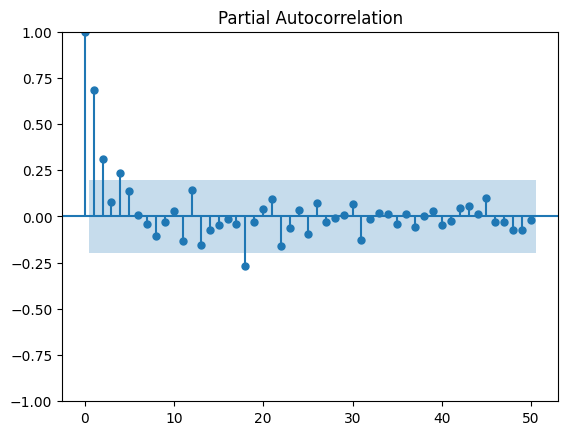

Lags for company = Moneymakers


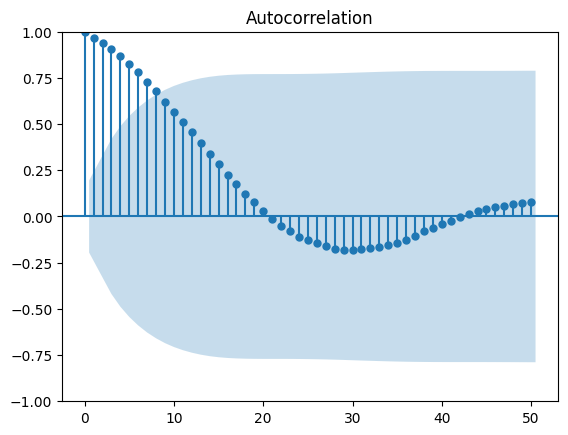

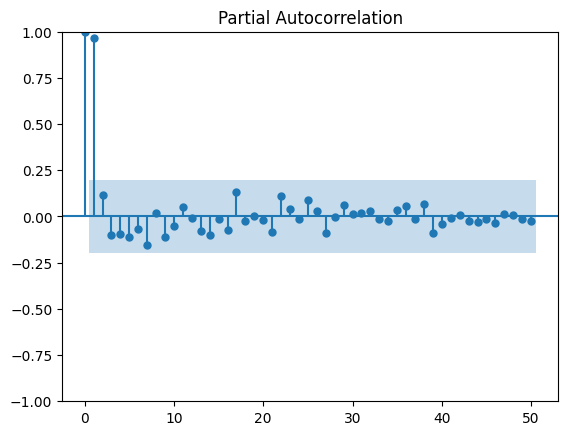

Lags for company = PearPear


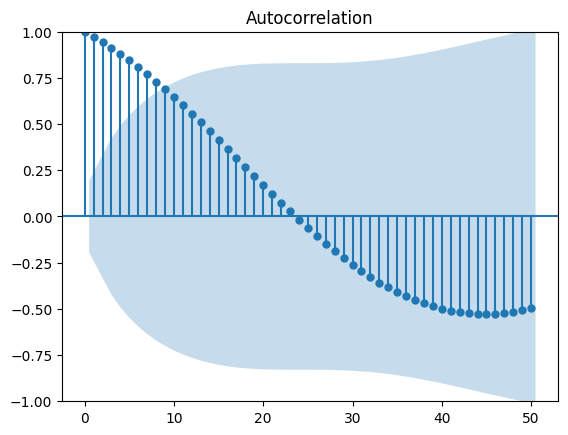

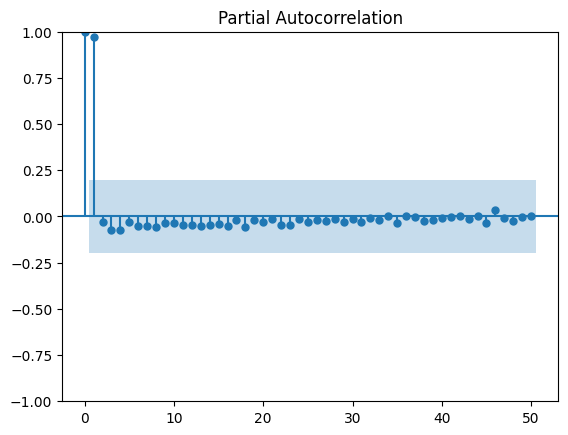

Lags for company = Photons


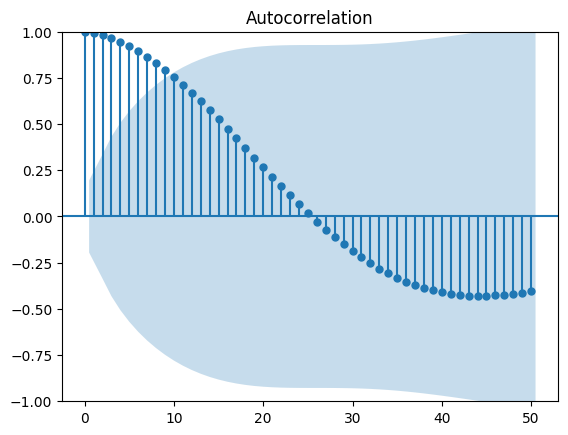

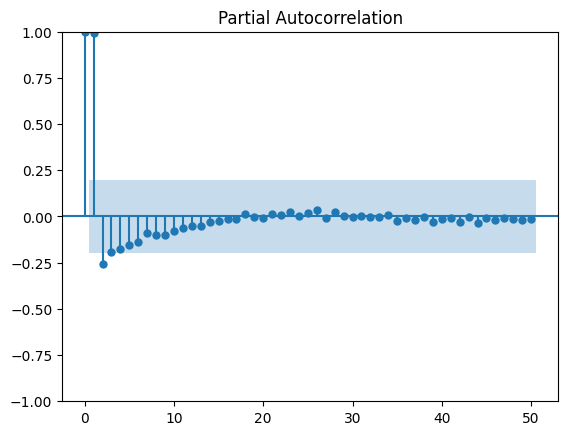

Lags for company = PositiveCorrelation


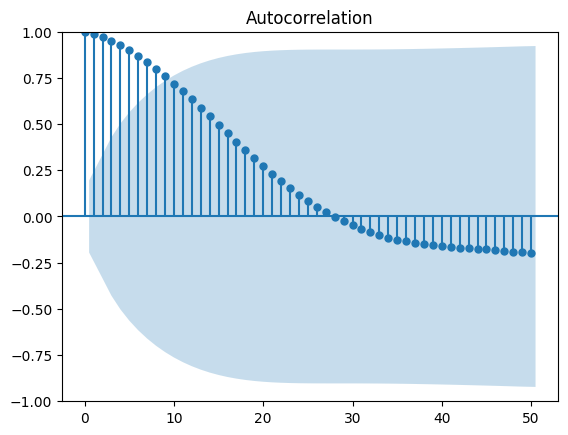

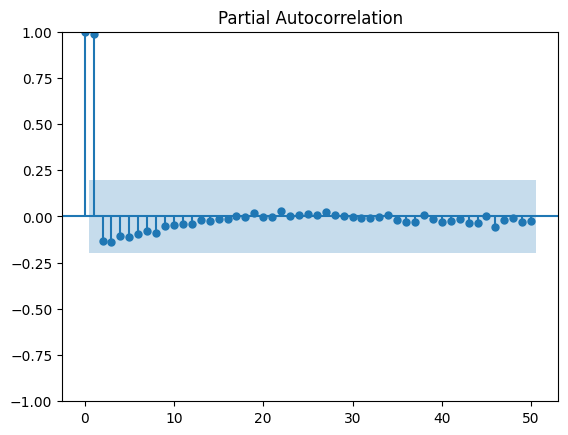

Lags for company = RoboticsX


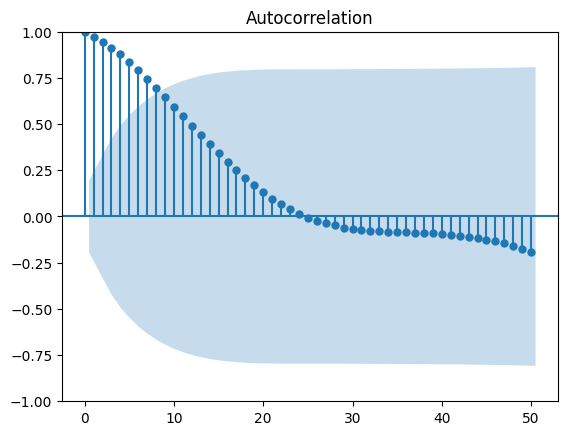

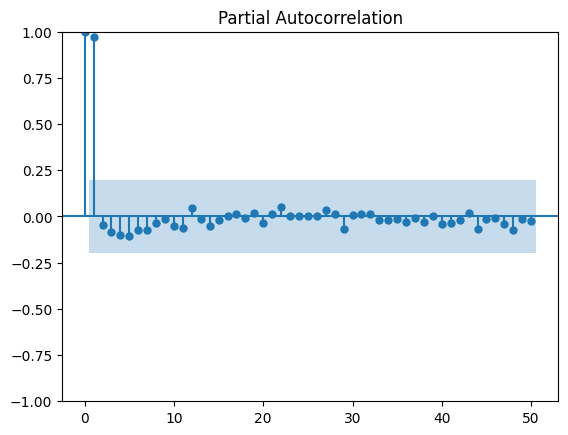

Lags for company = SafeAndCare


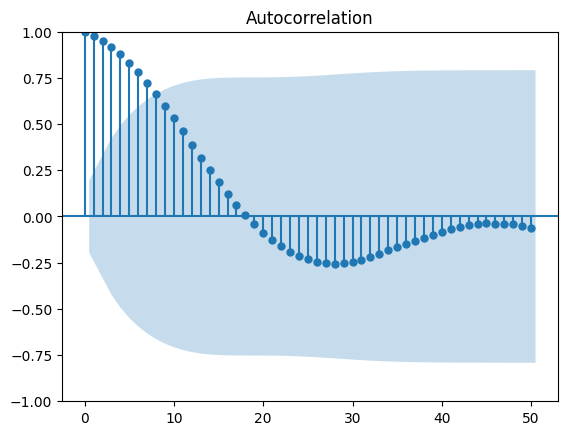

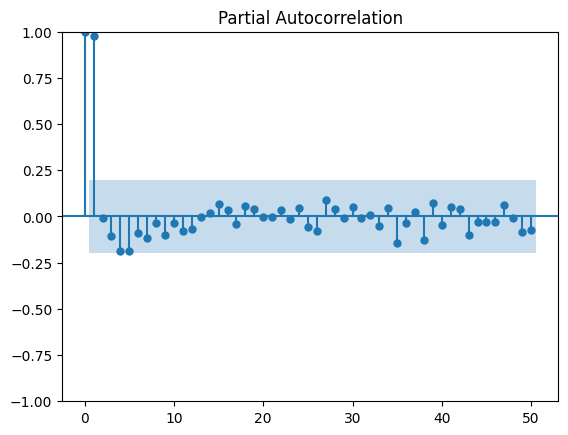

Lags for company = SpaceNow


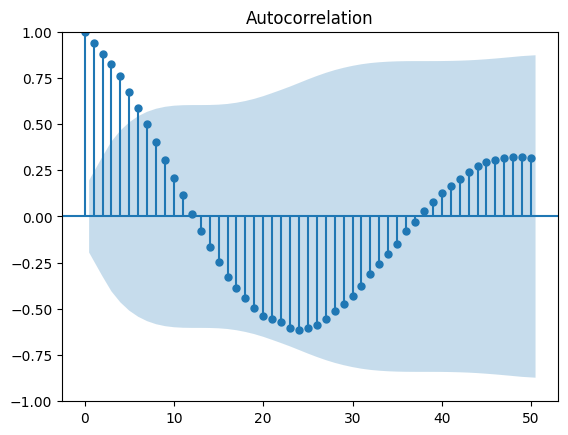

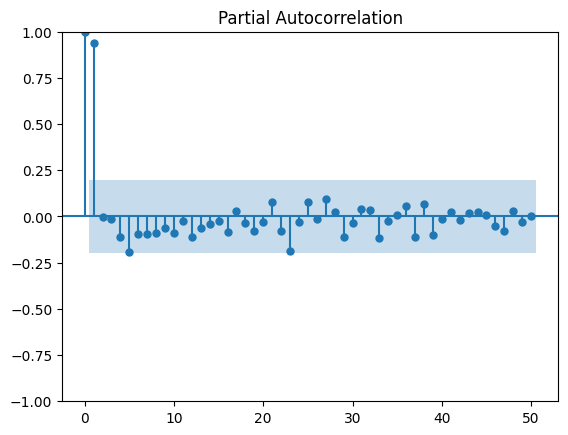

Lags for company = SuperFuture


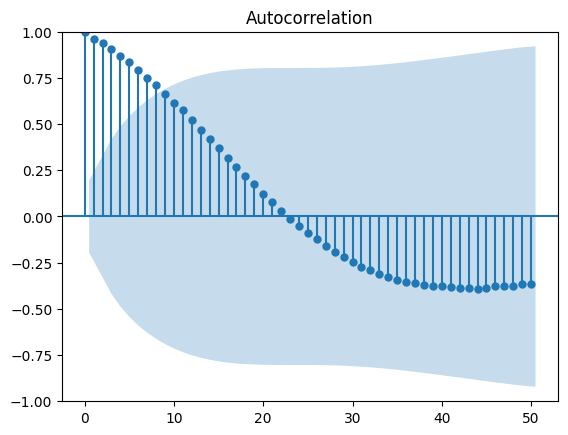

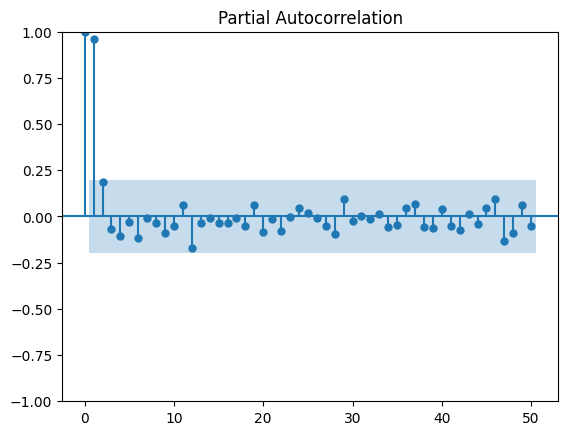

Lags for company = WaterForce


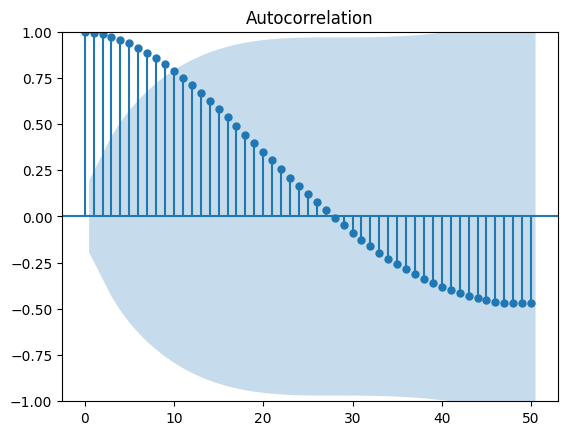

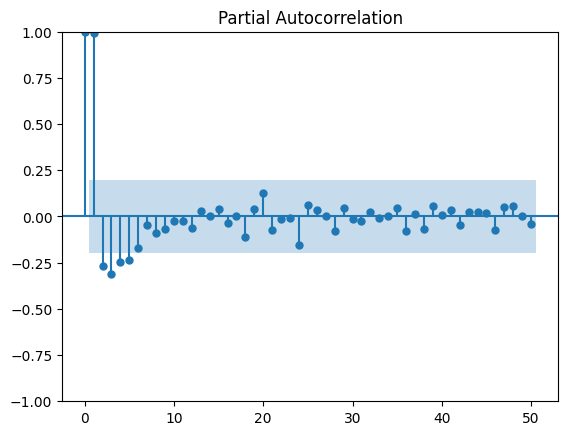

Lags for company = WorldNow


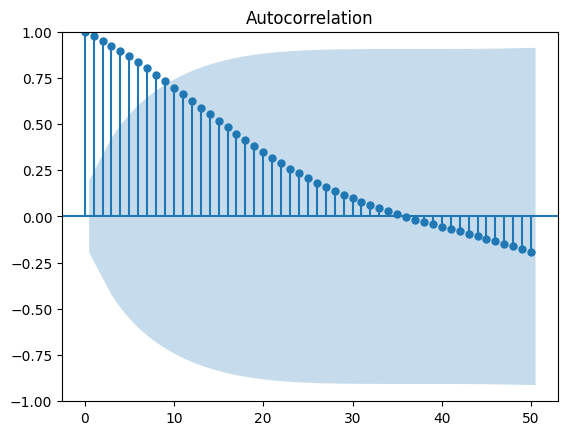

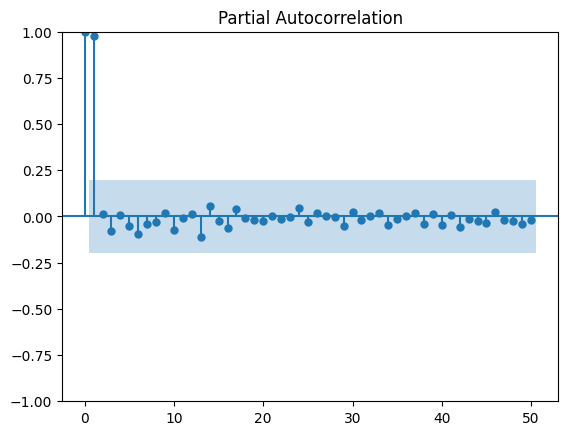

d:\MOO\MOO_env\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\MOO\MOO_env\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
d:\MOO\MOO_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


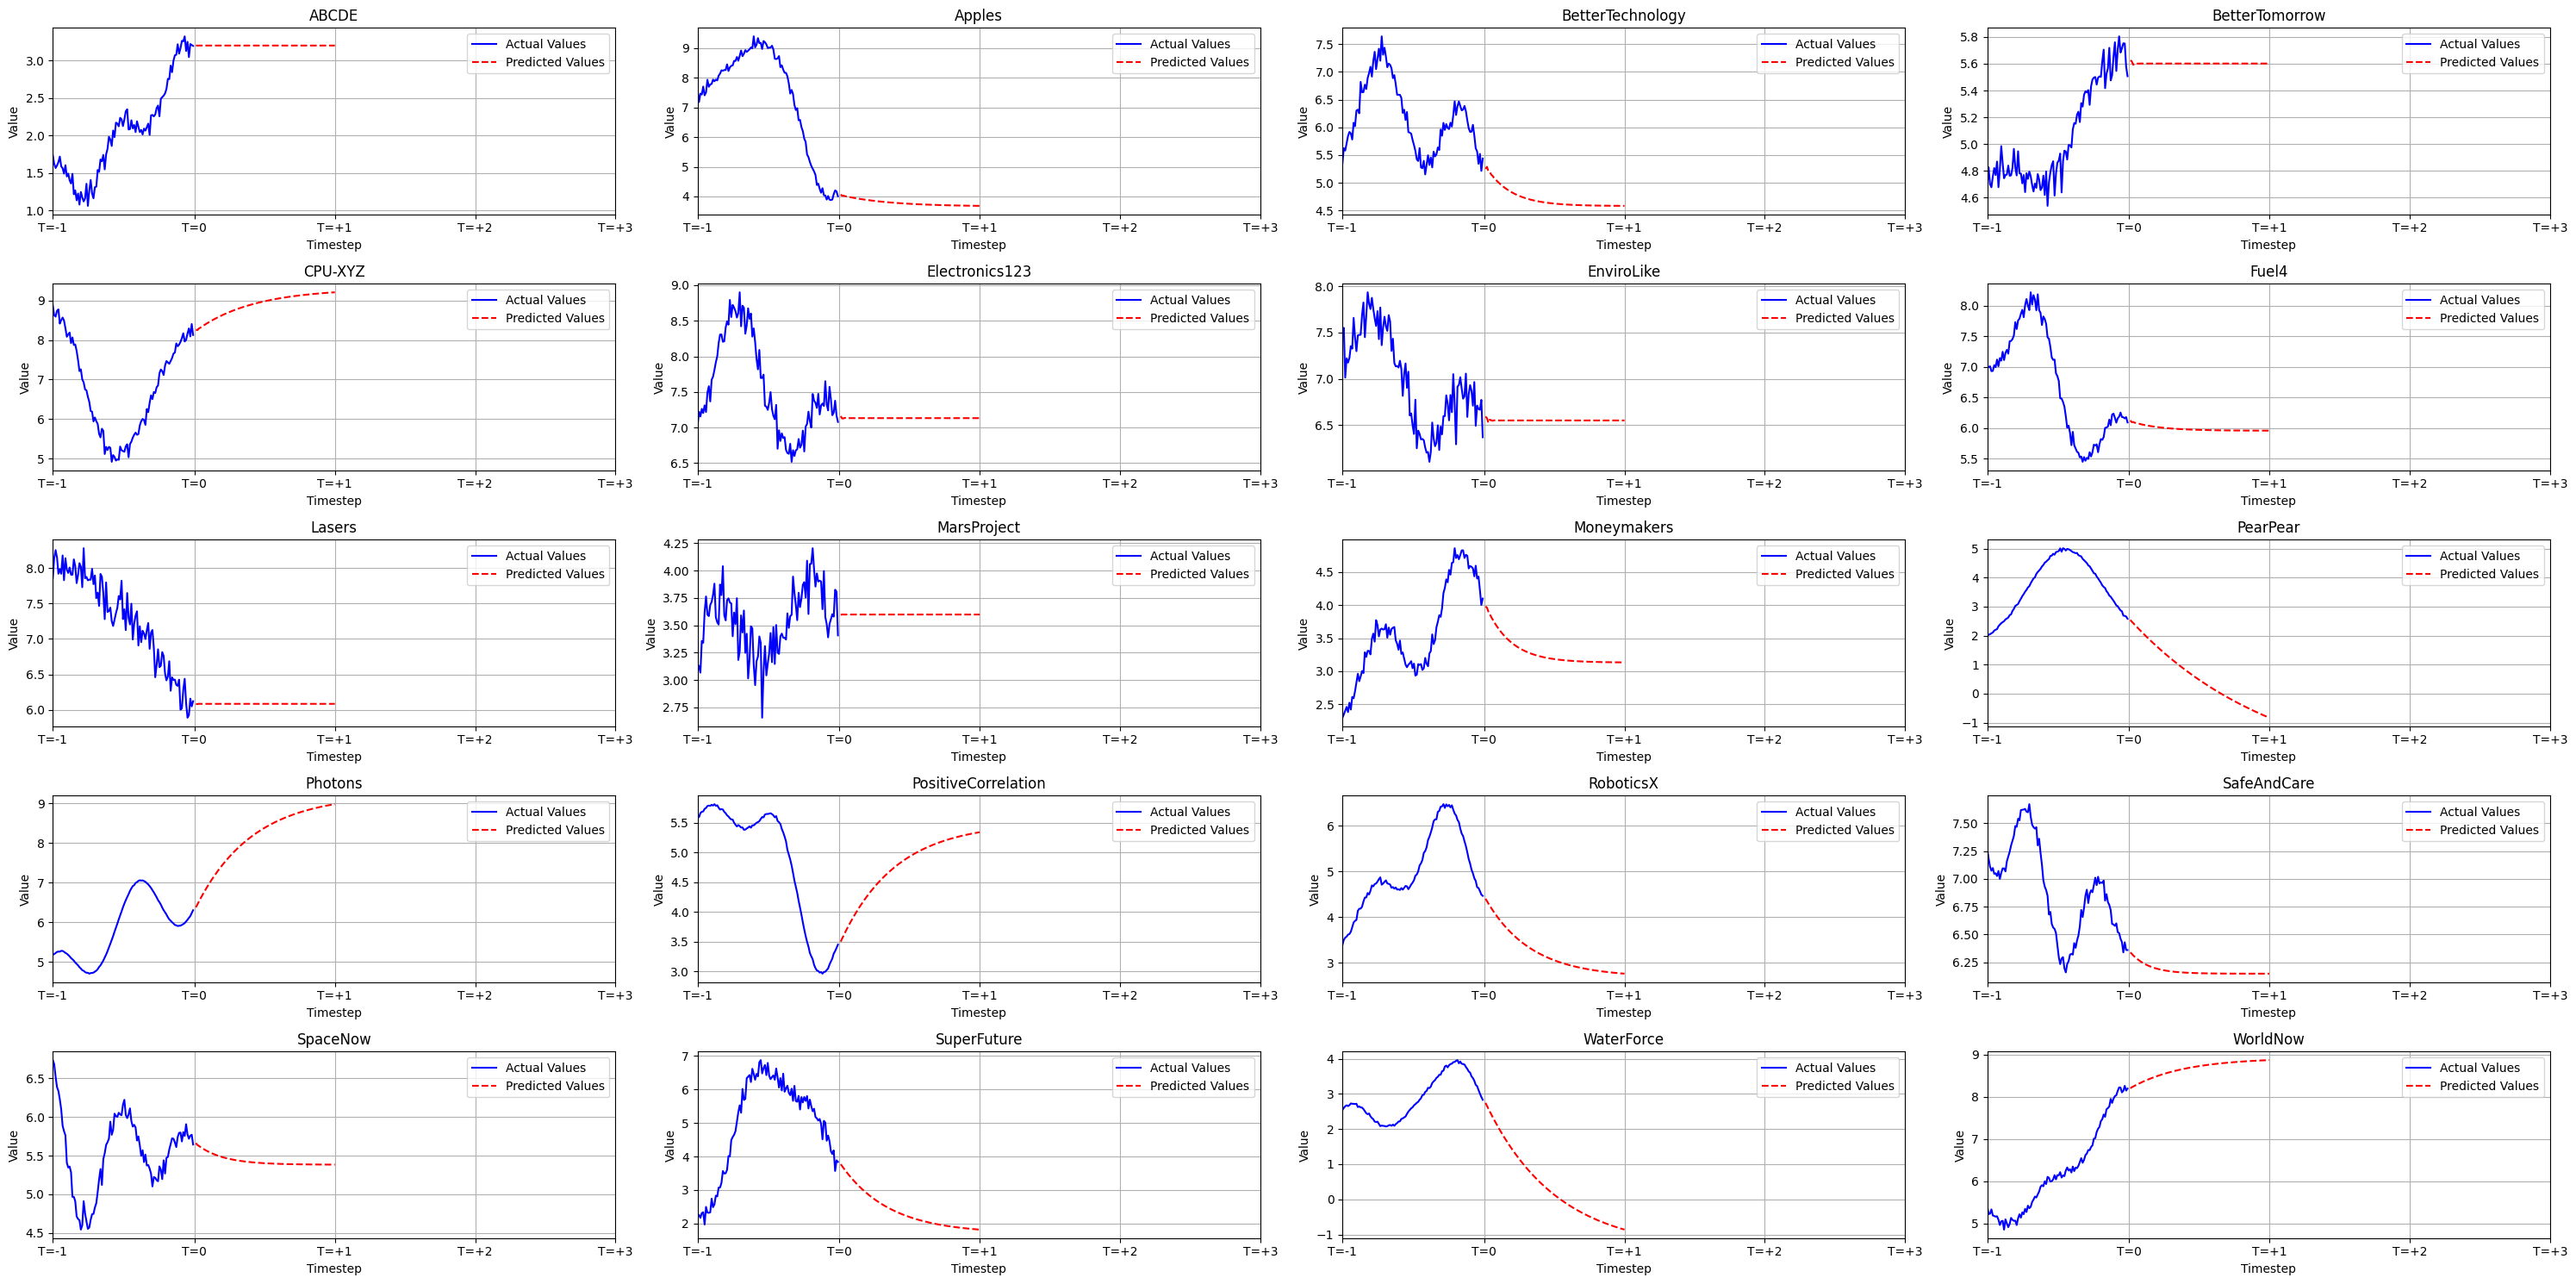

In [8]:
RMC = RegressionModelsCombined(data)
RMC.create_X_y(101)
RMC.plot_arima_lags(max_lags=50)
RMC.train_arima(p=2, d=1, q=1)
ARIMA_predictions = RMC.predict_arima()
RMC.plot_predictions(val_range=201, predictions=ARIMA_predictions, figsize=(30, 15))

### XGBoost

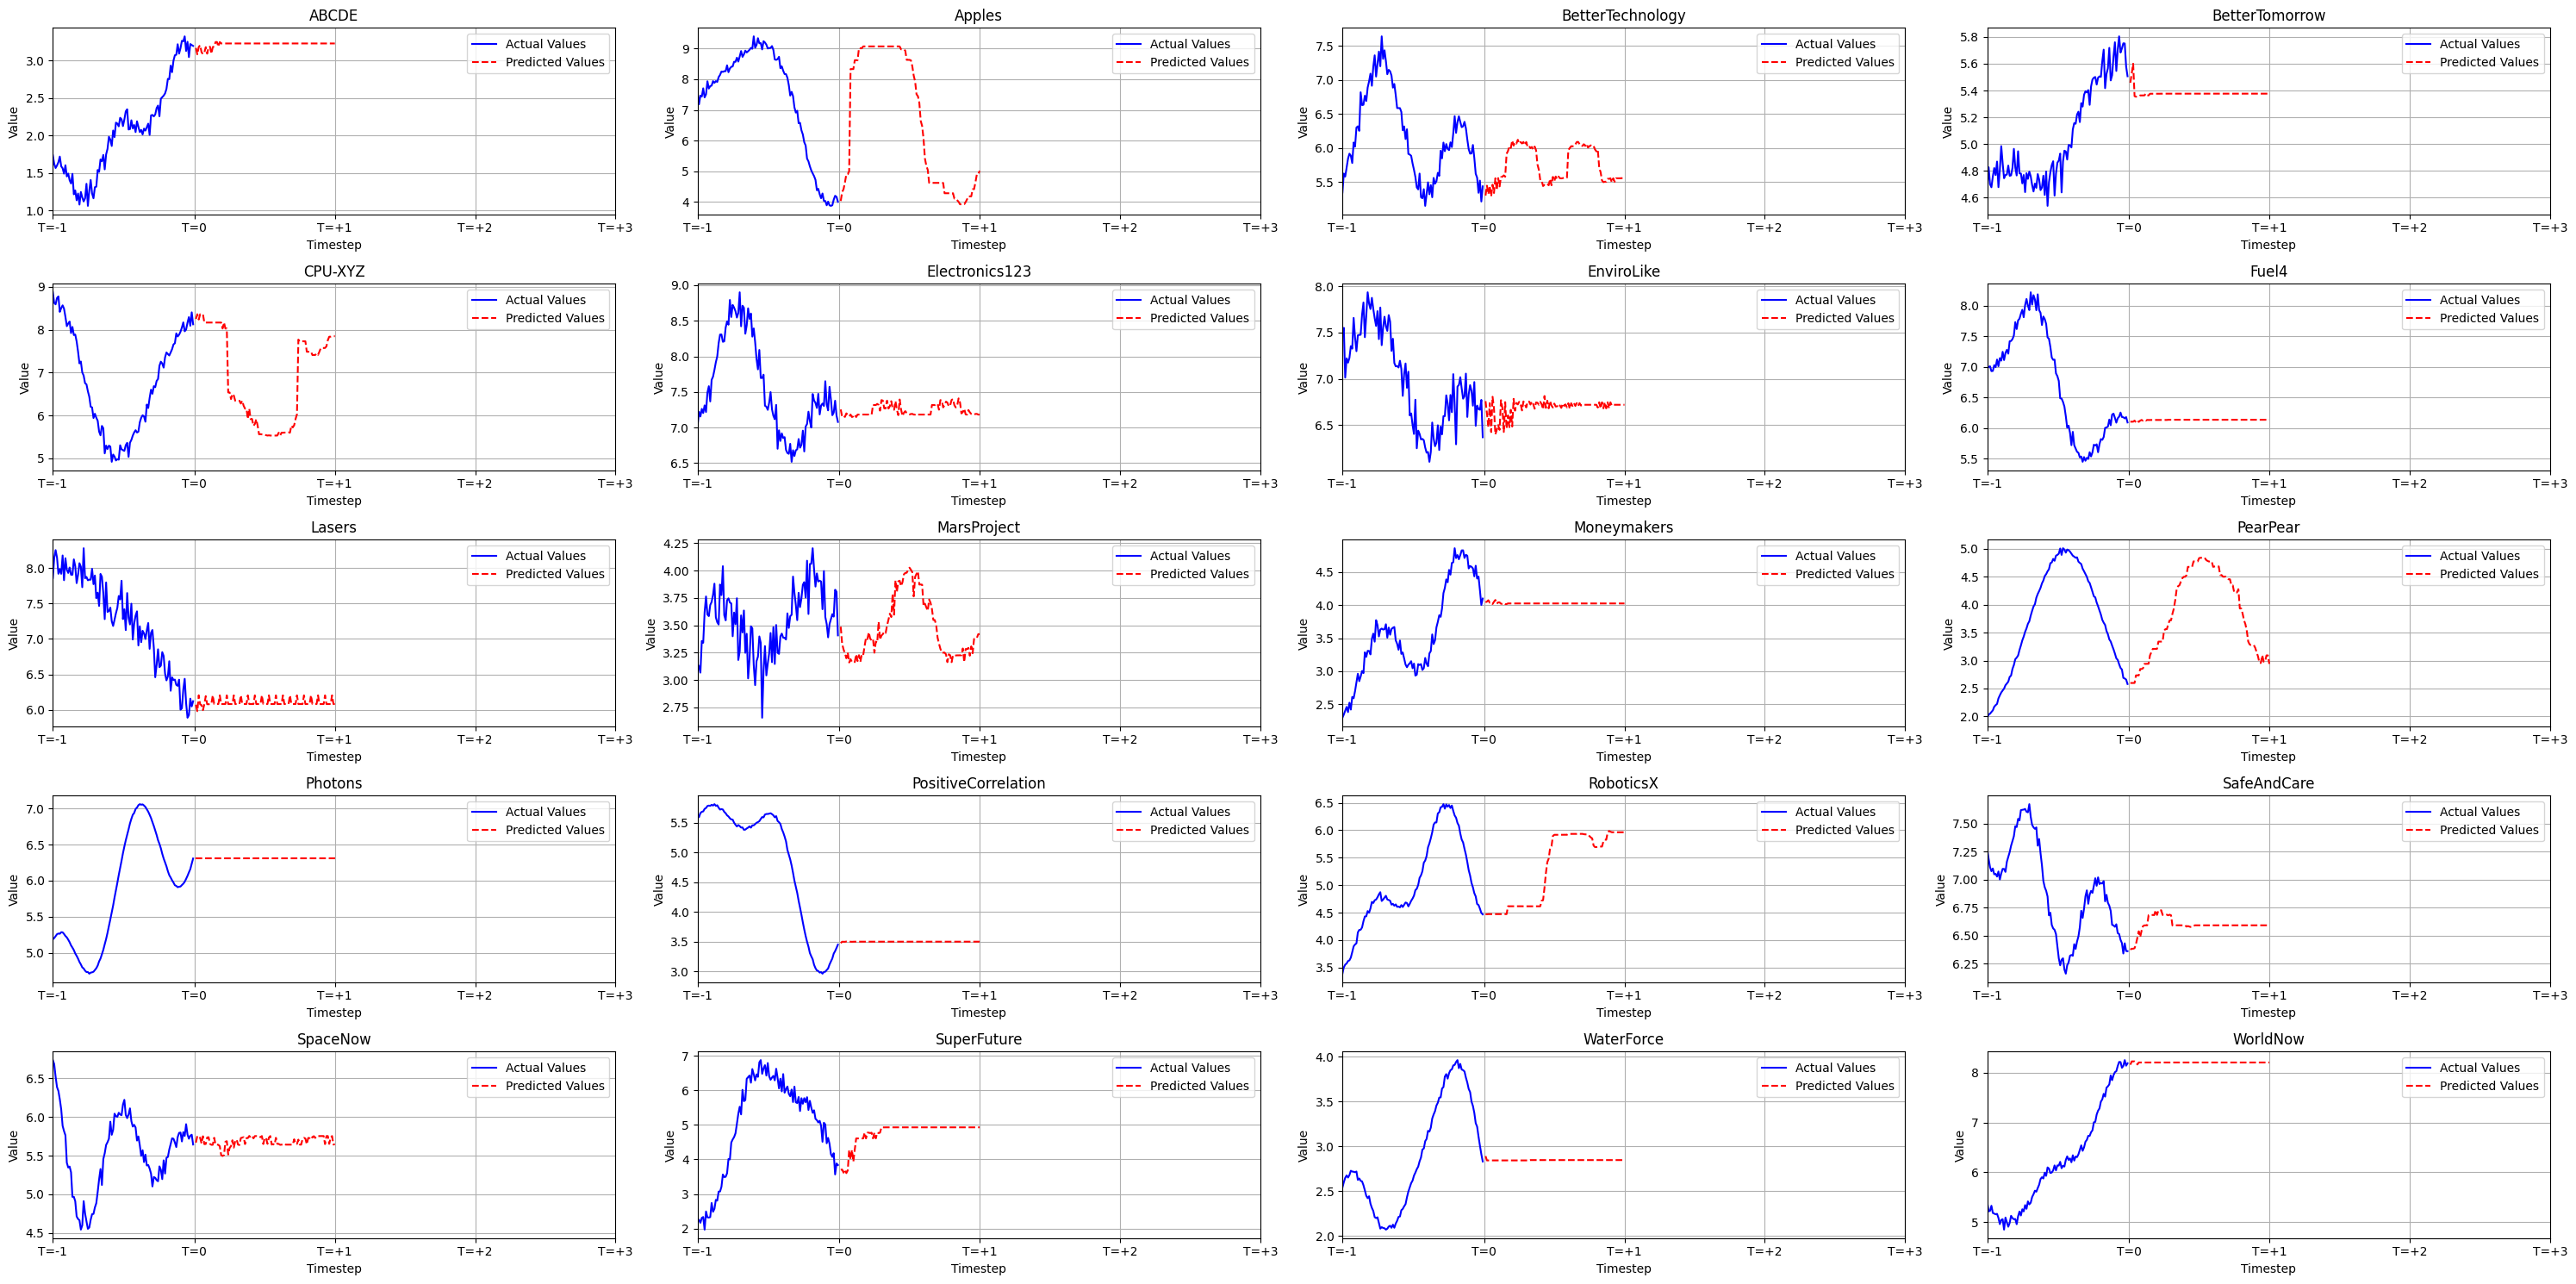

In [9]:
RMC = RegressionModelsCombined(data, window_size=50)
RMC.create_X_y_windows()
RMC.train_xgboost()
XGBoost_predictions = RMC.predict_xgboost()
RMC.plot_predictions(val_range=201, predictions=XGBoost_predictions, figsize=(30, 15))

### NODE

Using device: cpu
Company: ABCDE, Epoch 0, Loss: 4.144543170928955
Company: ABCDE, Epoch 100, Loss: 0.06090312451124191
Company: ABCDE, Epoch 200, Loss: 0.044455260038375854
Company: Apples, Epoch 0, Loss: 43.35454177856445
Company: Apples, Epoch 100, Loss: 1.3647462129592896
Company: Apples, Epoch 200, Loss: 0.4320058226585388
Company: BetterTechnology, Epoch 0, Loss: 31.4180965423584
Company: BetterTechnology, Epoch 100, Loss: 0.26679670810699463
Company: BetterTechnology, Epoch 200, Loss: 0.22472256422042847
Company: BetterTomorrow, Epoch 0, Loss: 11.519780158996582
Company: BetterTomorrow, Epoch 100, Loss: 0.030148115009069443
Company: BetterTomorrow, Epoch 200, Loss: 0.01529777143150568
Company: CPU-XYZ, Epoch 0, Loss: 66.70993041992188
Company: CPU-XYZ, Epoch 100, Loss: 1.0395607948303223
Company: CPU-XYZ, Epoch 200, Loss: 0.12797395884990692
Company: Electronics123, Epoch 0, Loss: 87.97222900390625
Company: Electronics123, Epoch 100, Loss: 0.28642818331718445
Company: Electronic

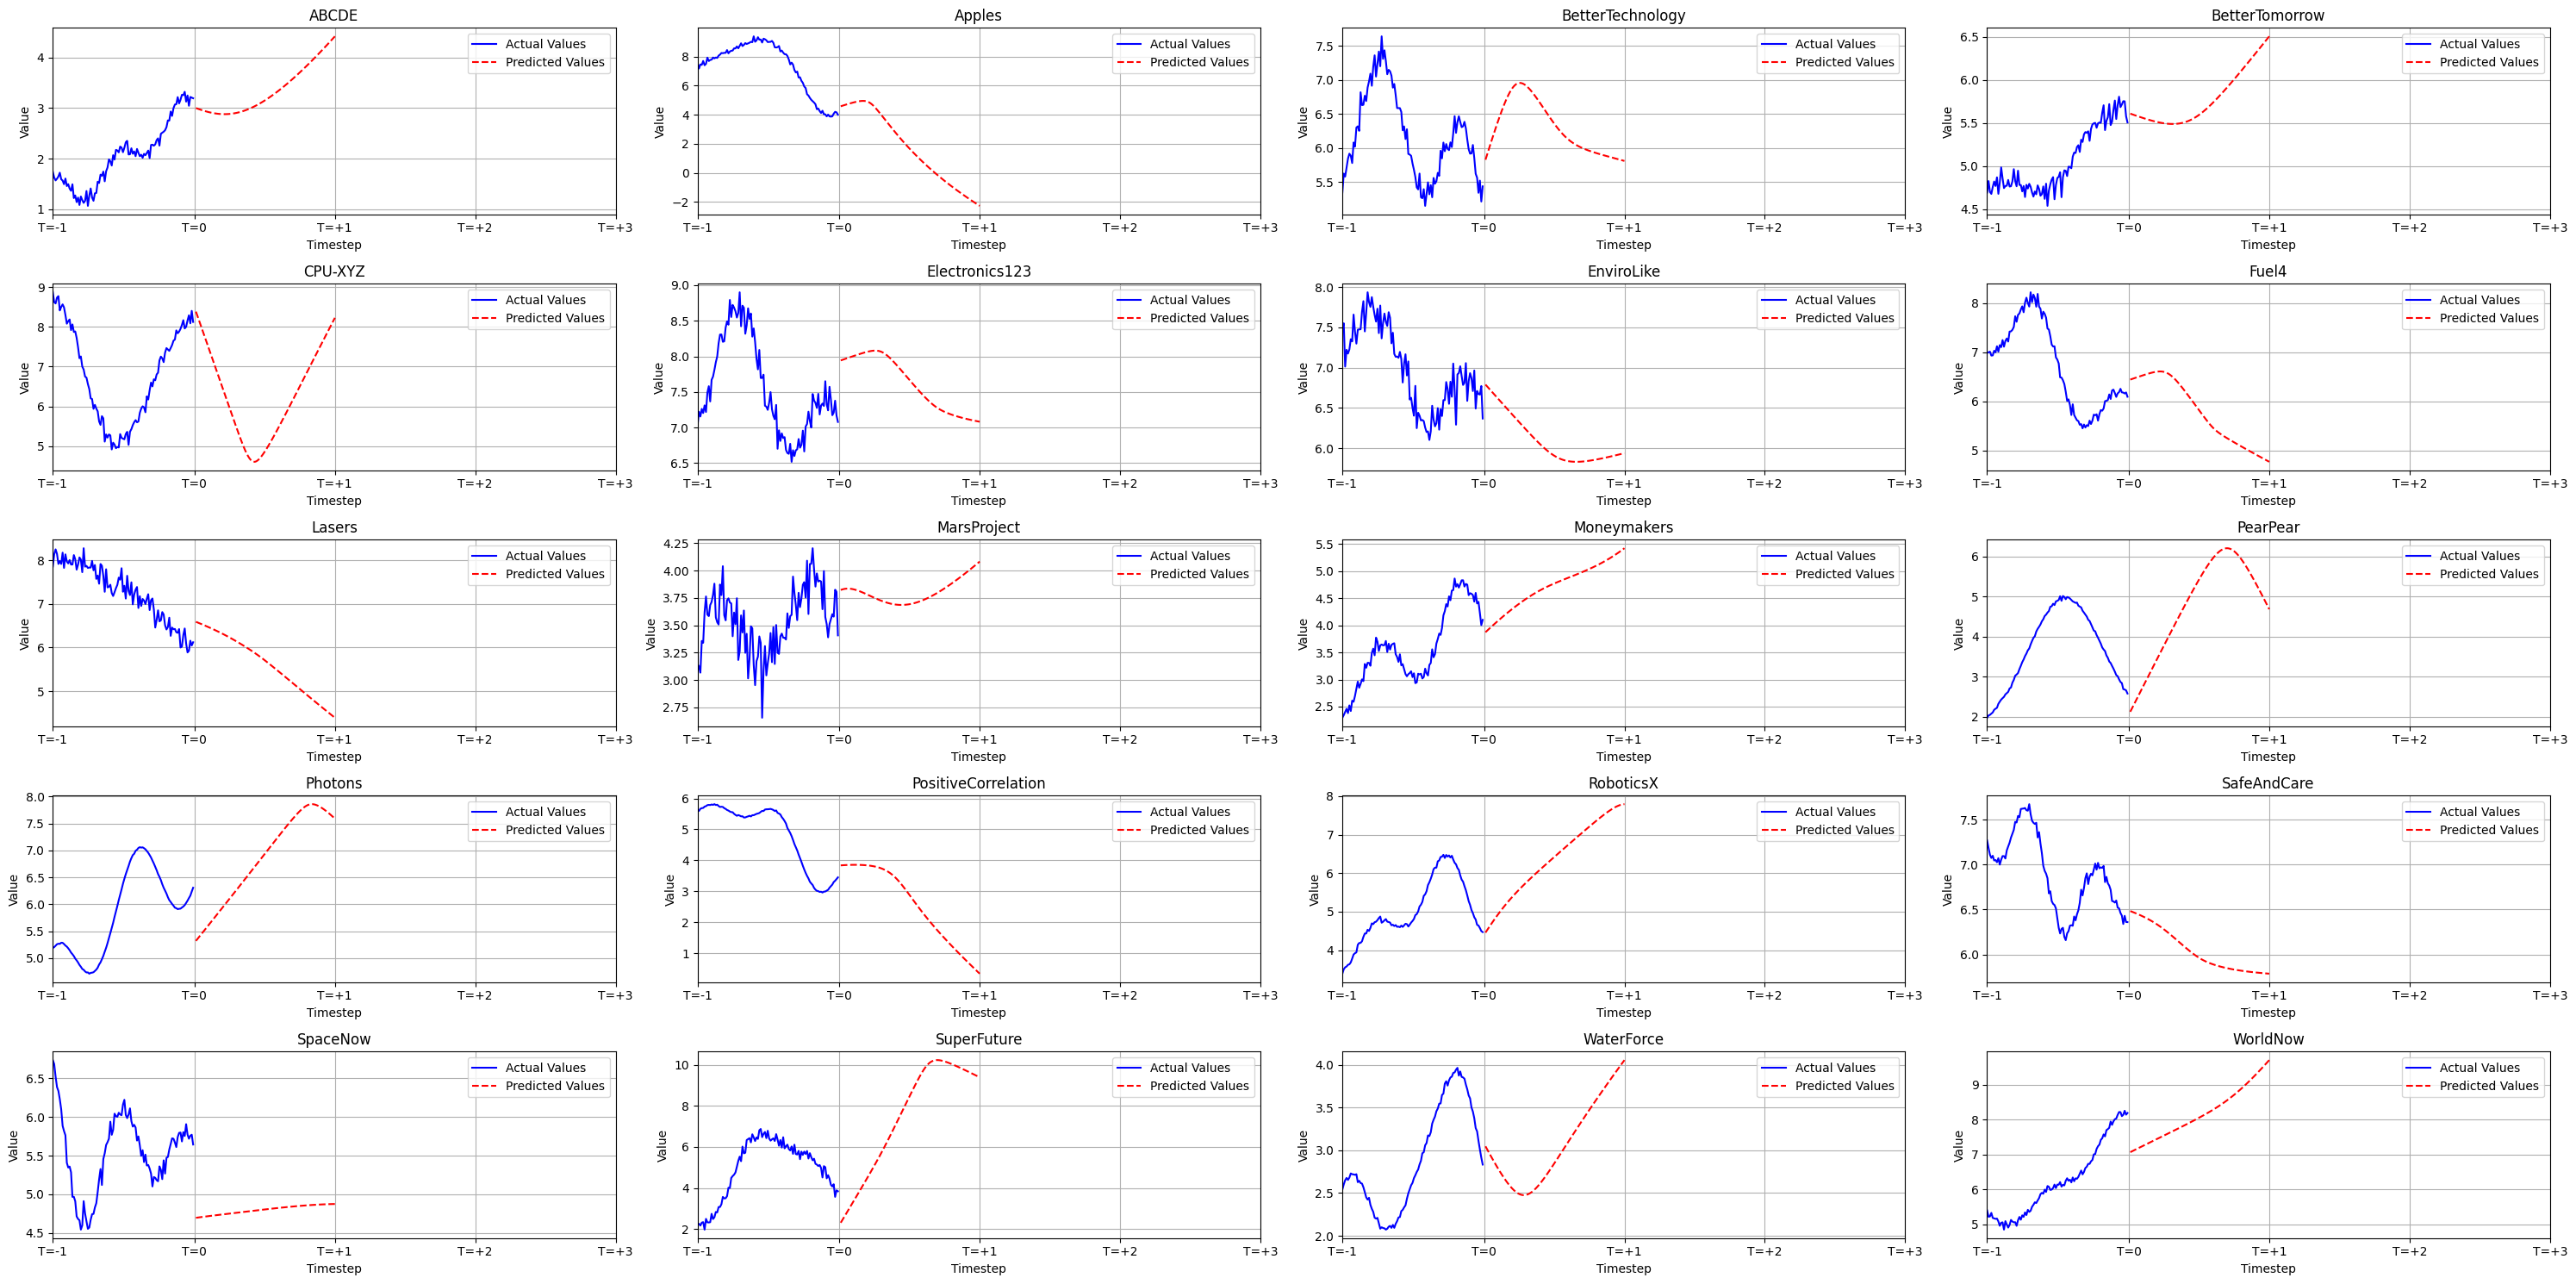

In [10]:
RMC = RegressionModelsCombined(data, window_size=50)
RMC.train_NODE()
NODE_predictions = RMC.predict_NODE()
RMC.plot_predictions(val_range=201, predictions=NODE_predictions, figsize=(30, 15))

## Single-Run WSM Run

In [11]:
risks = RMC.get_covariance_matrix()
solver = Solver(data, NODE_predictions, risks)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.6695e+00 -3.7498e+01  2e+02  3e+00  3e-16
 1: -9.6228e-01 -1.8441e+01  2e+01  1e-01  9e-16
 2: -6.5199e-01 -1.7744e+00  1e+00  1e-03  9e-16
 3: -1.2966e+00 -1.8175e+00  5e-01  3e-04  7e-16
 4: -1.4425e+00 -1.4512e+00  9e-03  5e-06  7e-16
 5: -1.4463e+00 -1.4464e+00  9e-05  5e-08  5e-16
 6: -1.4463e+00 -1.4463e+00  9e-07  5e-10  7e-16
Optimal solution found.


In [12]:
solutions = solver.solve_wsm()

Running for w1=0.0, w2=1.0
     pcost       dcost       gap    pres   dres
 0: -9.0929e-01 -2.9064e+01  1e+02  2e+00  6e-16
 1: -2.6085e-01 -1.1942e+01  1e+01  4e-02  2e-15
 2: -2.4176e-01 -1.6994e+00  2e+00  4e-03  1e-15
 3: -5.4277e-01 -1.3806e+00  9e-01  1e-03  4e-16
 4: -6.9627e-01 -7.3214e-01  4e-02  4e-05  7e-16
 5: -7.1121e-01 -7.1157e-01  4e-04  4e-07  6e-16
 6: -7.1136e-01 -7.1136e-01  4e-06  4e-09  4e-16
 7: -7.1136e-01 -7.1136e-01  4e-08  4e-11  5e-16
Optimal solution found.
Running for w1=0.1, w2=0.9
     pcost       dcost       gap    pres   dres
 0: -5.2258e-01 -2.6850e+01  1e+02  2e+00  1e-15
 1: -2.0302e-01 -1.0509e+01  1e+01  4e-02  2e-15
 2: -1.8695e-01 -1.3059e+00  1e+00  3e-03  8e-16
 3: -4.0584e-01 -9.5951e-01  6e-01  4e-04  6e-16
 4: -4.8608e-01 -5.2477e-01  4e-02  2e-05  7e-16
 5: -5.0609e-01 -5.0670e-01  6e-04  2e-07  4e-16
 6: -5.0650e-01 -5.0651e-01  6e-06  2e-09  4e-16
 7: -5.0651e-01 -5.0651e-01  6e-08  2e-11  5e-16
Optimal solution found.
Running for w1=0.2

In [13]:
pretty_display(solutions)

,Expected Gain,Risk,SuperFuture,Apples,WorldNow,Electronics123,Photons,SpaceNow,PearPear,PositiveCorrelation,...,Moneymakers,Fuel4,MarsProject,CPU-XYZ,RoboticsX,Lasers,WaterForce,SafeAndCare,BetterTomorrow,Sanity Check
0,1.446334,2.033381,1.000000,3.987643e-10,1.474456e-09,1.253988e-09,1.497065e-09,1.108229e-09,4.599821e-10,5.986380e-10,...,1.636554e-09,1.030887e-09,1.489963e-09,1.268051e-09,1.128611e-09,9.732531e-10,1.733059e-09,1.155404e-09,1.469772e-09,1.0
1,1.446334,2.033381,1.000000,7.364564e-10,4.547500e-09,5.083569e-09,3.736541e-09,3.470706e-09,1.090801e-09,1.490303e-09,...,7.797030e-09,3.667536e-09,9.168216e-09,5.041509e-08,2.147368e-08,3.503149e-09,1.730801e-08,4.807620e-09,7.185515e-09,1.0
2,1.140498,0.824554,0.786656,4.944107e-10,1.512500e-09,1.810498e-09,1.537349e-09,1.346351e-09,3.013248e-09,7.976762e-10,...,2.074323e-09,1.476170e-09,2.340824e-09,2.133436e-01,4.663389e-09,1.405512e-09,3.011210e-09,1.647516e-09,1.984642e-09,1.0
3,0.942108,0.354679,0.648264,1.073155e-10,1.793203e-10,6.830696e-10,2.459485e-10,2.417713e-10,9.102630e-10,1.841315e-10,...,3.494911e-10,5.161411e-10,7.062886e-10,3.517359e-01,1.632844e-09,4.365607e-10,6.550419e-10,4.551357e-10,3.845510e-10,1.0
4,0.842913,0.212480,0.579068,1.414635e-10,4.501939e-11,1.780731e-09,1.009471e-10,1.637126e-10,1.363696e-09,2.807509e-10,...,1.230970e-10,1.618816e-09,6.527141e-10,4.209321e-01,2.835502e-10,9.990648e-10,1.111906e-10,6.442042e-10,1.879288e-10,1.0
5,0.783389,0.156832,0.537547,6.305854e-10,1.407754e-10,3.816821e-07,2.215653e-10,3.842717e-10,5.626805e-09,2.240158e-09,...,2.737718e-10,7.581909e-06,1.799393e-09,4.624452e-01,4.406480e-10,9.380978e-08,3.598297e-10,4.667744e-09,3.980659e-10,1.0
6,0.670072,0.087284,0.472722,1.676734e-09,1.124465e-09,1.484570e-08,2.099107e-09,2.457765e-09,9.119838e-08,5.146021e-09,...,1.877111e-09,6.751300e-02,6.998894e-09,4.433846e-01,4.834438e-09,1.638037e-02,3.676705e-09,5.892480e-09,2.875603e-09,1.0
7,0.562323,0.043152,0.415864,1.431728e-09,1.386982e-09,3.357414e-08,2.896648e-09,2.967010e-09,1.403023e-05,2.588617e-09,...,2.157581e-09,6.321327e-02,8.421122e-09,4.123959e-01,5.755415e-09,1.085131e-01,4.462096e-09,4.892176e-09,3.648697e-09,1.0
8,0.457349,0.016670,0.229728,3.394789e-10,2.720610e-10,3.022194e-08,6.469797e-10,5.087661e-10,2.021077e-01,2.080739e-10,...,4.964979e-10,1.282267e-01,2.953233e-09,3.813647e-01,1.980637e-09,5.857294e-02,1.234450e-09,1.934924e-09,8.956080e-10,1.0
9,0.373687,0.005372,0.073010,8.077171e-09,4.231508e-09,5.588733e-07,7.516816e-09,7.392677e-09,3.761122e-01,2.111798e-08,...,7.975929e-09,1.844597e-01,4.454624e-08,3.565773e-01,1.681241e-08,9.839716e-03,1.308918e-08,4.018997e-08,1.319194e-08,1.0


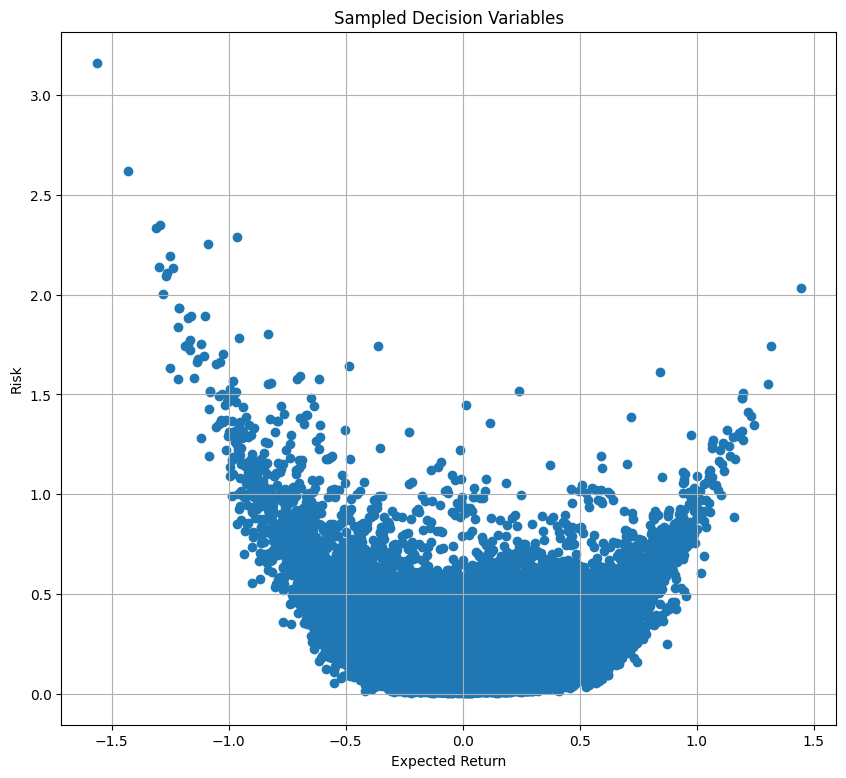

In [14]:
solver.plot_sampled_decision_variables(20, 0.2)

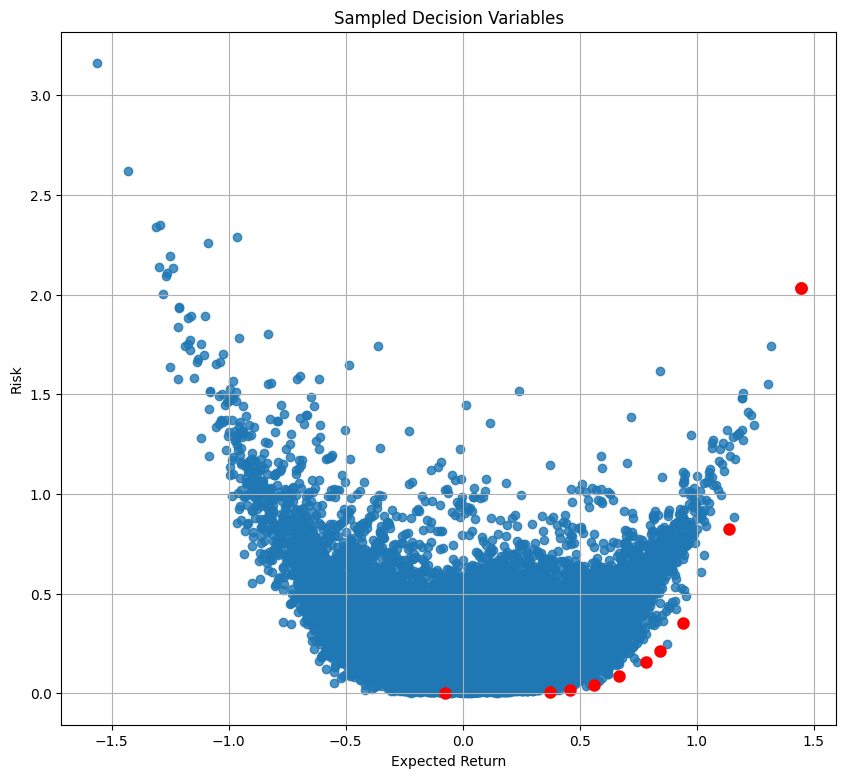

In [15]:
solver.plot_front(solutions, n=20, step=0.2)

### Single-Run ECM Algorithm

In [16]:
solutions = solver.solve_ecm()

Running for threshold=-0.07435369612196875
     pcost       dcost       gap    pres   dres
 0:  1.7397e-03 -2.1859e+01  2e+01  4e-15  5e+00
 1:  1.4299e-03 -5.0194e-01  5e-01  1e-16  1e-01
 2:  7.4309e-04 -4.0032e-02  4e-02  2e-16  1e-02
 3:  3.3320e-04 -1.8136e-03  2e-03  2e-16  8e-05
 4:  2.1709e-04 -5.8553e-05  3e-04  1e-16  3e-06
 5:  1.8252e-04  1.4807e-04  3e-05  1e-16  2e-16
 6:  1.7685e-04  1.7542e-04  1e-06  2e-16  2e-16
 7:  1.7640e-04  1.7633e-04  7e-08  1e-16  8e-17
Optimal solution found.
Running for threshold=0.07771507893616646
     pcost       dcost       gap    pres   dres
 0:  3.0150e-03 -2.1284e+01  8e+01  1e+00  5e+00
 1:  8.3283e-02 -8.2335e+00  1e+01  9e-02  3e-01
 2:  2.8399e-02 -7.2102e-01  8e-01  2e-03  6e-03
 3:  1.1222e-02 -8.2606e-02  9e-02  2e-04  6e-04
 4:  1.8719e-03 -2.2776e-02  2e-02  4e-16  2e-16
 5:  9.5243e-04 -2.7647e-03  4e-03  2e-16  1e-16
 6:  5.4410e-04 -4.8133e-04  1e-03  2e-16  2e-16
 7:  4.0443e-04  2.1411e-04  2e-04  2e-16  2e-16
 8:  3.8069

In [17]:
pretty_display(solutions)

,Expected Gain,Risk,SuperFuture,Apples,WorldNow,Electronics123,Photons,SpaceNow,PearPear,PositiveCorrelation,...,Moneymakers,Fuel4,MarsProject,CPU-XYZ,RoboticsX,Lasers,WaterForce,SafeAndCare,BetterTomorrow,Sanity Check
0,-0.073322,0.000176,5.206726e-07,4.348898e-06,1.042467e-01,2.682891e-02,1.297293e-01,1.991079e-02,1.051077e-06,1.825261e-01,...,4.117684e-02,8.324656e-02,7.138059e-03,4.387507e-02,2.478928e-03,6.488497e-06,7.993185e-02,1.474579e-01,3.852078e-02,1.0
1,0.077715,0.000376,1.992912e-07,4.137293e-08,1.463586e-03,5.397112e-02,2.019430e-01,2.665408e-02,1.051720e-01,4.855412e-02,...,2.141254e-06,1.460583e-01,1.359539e-02,1.233747e-01,5.018760e-07,5.597439e-05,4.270410e-03,1.149765e-01,6.466897e-02,1.0
2,0.229784,0.001256,1.747035e-08,4.056892e-09,6.827618e-09,4.269795e-02,1.075863e-01,1.458865e-02,3.067028e-01,1.830119e-04,...,6.411137e-09,2.036196e-01,3.019804e-07,2.581924e-01,1.774680e-08,1.892770e-02,1.557002e-08,6.679655e-07,3.895726e-02,1.0
3,0.381853,0.006092,8.826389e-02,6.023989e-10,5.584333e-10,3.698612e-08,1.232983e-09,1.127294e-09,3.591931e-01,2.970921e-09,...,1.069559e-09,1.790044e-01,5.690031e-09,3.589982e-01,3.225578e-09,1.454042e-02,2.393825e-09,4.274281e-09,2.170671e-09,1.0
4,0.533921,0.034628,3.732076e-01,7.140700e-10,5.828169e-10,3.109494e-08,1.245829e-09,1.024984e-09,4.278345e-02,2.357150e-09,...,1.025202e-09,7.672501e-02,4.807222e-09,4.040497e-01,3.369411e-09,1.032341e-01,2.137554e-09,2.756298e-09,1.706270e-09,1.0
5,0.685990,0.095430,4.811205e-01,5.639576e-11,2.833133e-11,5.696006e-11,7.192628e-11,7.919481e-11,4.160699e-09,2.025933e-10,...,5.006791e-11,6.814877e-02,2.571715e-10,4.479626e-01,1.526943e-10,2.768118e-03,1.131351e-10,2.078163e-10,9.120325e-11,1.0
6,0.838059,0.207109,5.756821e-01,4.857500e-10,1.972811e-10,7.031246e-09,4.782765e-10,7.320963e-10,5.609426e-09,1.035579e-09,...,4.693423e-10,6.356660e-09,2.497349e-09,4.243179e-01,7.185377e-10,3.878340e-09,6.042943e-10,2.444638e-09,8.542269e-10,1.0
7,0.990128,0.445726,6.817615e-01,1.019146e-09,1.697426e-09,5.334221e-09,2.282458e-09,2.277675e-09,7.834429e-09,1.676401e-09,...,2.946158e-09,3.968668e-09,5.606422e-09,3.182385e-01,5.670992e-09,3.367757e-09,4.237230e-09,3.867739e-09,3.462772e-09,1.0
8,1.142197,0.829643,7.878409e-01,1.234710e-10,3.486991e-10,4.748988e-10,3.543564e-10,2.864152e-10,7.403075e-10,1.858386e-10,...,5.371489e-10,3.078719e-10,6.848851e-10,2.121591e-01,3.869550e-10,2.633415e-10,5.726232e-10,4.117041e-10,5.232303e-10,1.0
9,1.294265,1.358861,8.939203e-01,-2.051265e-10,3.024362e-10,1.957580e-10,4.574796e-11,-1.390932e-10,-2.847285e-10,-9.916542e-11,...,1.005703e-09,-2.972312e-10,1.085566e-09,1.060797e-01,5.924630e-09,-4.525507e-10,3.725692e-09,8.062099e-11,6.861882e-10,1.0


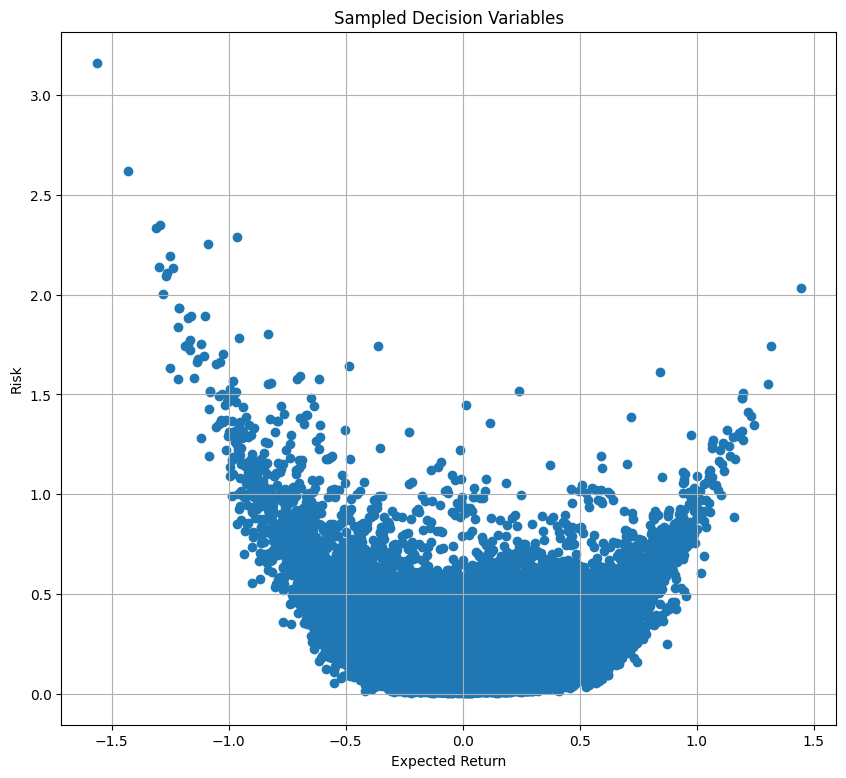

In [18]:
solver.plot_sampled_decision_variables(20, 0.2)

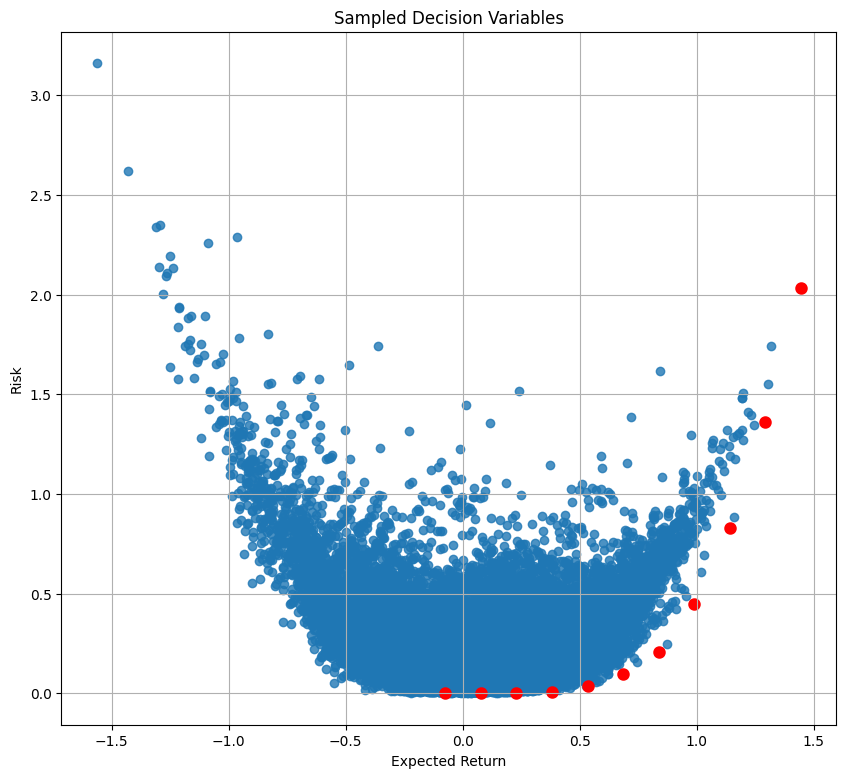

In [19]:
solver.plot_front(solutions, n=20, step=0.2)

## Comparison

### Single Threshold/Step Tests

In [20]:
thresholds = [20]
steps = [1/20]

ER = ExperimentRunner(solver=solver)
ER.run_ECM(thresholds)
ER.run_WSM(steps)

Running for threshold=-0.07435369612196875
     pcost       dcost       gap    pres   dres
 0:  1.7397e-03 -2.1859e+01  2e+01  4e-15  5e+00
 1:  1.4299e-03 -5.0194e-01  5e-01  1e-16  1e-01
 2:  7.4309e-04 -4.0032e-02  4e-02  2e-16  1e-02
 3:  3.3320e-04 -1.8136e-03  2e-03  2e-16  8e-05
 4:  2.1709e-04 -5.8553e-05  3e-04  1e-16  3e-06
 5:  1.8252e-04  1.4807e-04  3e-05  1e-16  2e-16
 6:  1.7685e-04  1.7542e-04  1e-06  2e-16  2e-16
 7:  1.7640e-04  1.7633e-04  7e-08  1e-16  8e-17
Optimal solution found.
Running for threshold=0.005682501277049765
     pcost       dcost       gap    pres   dres
 0:  2.1857e-03 -2.1558e+01  2e+01  5e-15  5e+00
 1:  1.8931e-03 -5.6101e-01  6e-01  2e-16  1e-01
 2:  9.8859e-04 -4.2382e-02  4e-02  1e-16  1e-02
 3:  4.1967e-04 -2.3571e-03  3e-03  2e-16  1e-16
 4:  2.8042e-04  6.3351e-06  3e-04  1e-16  1e-16
 5:  2.4767e-04  1.9421e-04  5e-05  2e-16  1e-16
 6:  2.3721e-04  2.3464e-04  3e-06  2e-16  1e-16
 7:  2.3637e-04  2.3626e-04  1e-07  2e-16  1e-16
 8:  2.363

In [21]:
top_ecm, top_wsm = ER.summarize()
top_wsm

,Solution Signature,Frequency,Method
0,"(0.9999999771136435, 3.987643260182986e-10, 1....",1,WSM
1,"(0.9999999603579774, 5.309864847618439e-10, 2....",1,WSM
2,"(0.9999998324524654, 7.364563630011672e-10, 4....",1,WSM
3,"(0.9250486280357108, 1.366244031464843e-10, 4....",1,WSM
4,"(0.7866563391070497, 4.944107344772483e-10, 1....",1,WSM
5,"(0.7036206585235021, 5.5514575497956324e-09, 1...",1,WSM
6,"(0.6482640706635595, 1.0731547132678406e-10, 1...",1,WSM
7,"(0.6087234186226249, 1.0033238741033776e-10, 5...",1,WSM
8,"(0.5790679267636822, 1.4146345937779953e-10, 4...",1,WSM
9,"(0.5560025339398327, 2.3287482882842595e-10, 4...",1,WSM


In [22]:
top_ecm

,Solution Signature,Frequency,Method
0,"(5.206725885086166e-07, 4.348897571917353e-06,...",1,ECM
1,"(3.822531928734941e-08, 5.5516312061328095e-09...",1,ECM
2,"(1.3257486600931768e-07, 4.3640882302800775e-0...",1,ECM
3,"(8.42646521005087e-08, 2.8758423431142888e-08,...",1,ECM
4,"(3.6060658079476565e-07, 1.0541033492182095e-0...",1,ECM
5,"(0.003546152057389678, 5.096209978546451e-09, ...",1,ECM
6,"(0.13325424687737078, 3.5256341159312707e-10, ...",1,ECM
7,"(0.283225006249617, 1.379058358026367e-10, 1.5...",1,ECM
8,"(0.4177701159609852, 3.1280964506006585e-09, 2...",1,ECM
9,"(0.46000656122416356, 1.715046242010409e-10, 1...",1,ECM


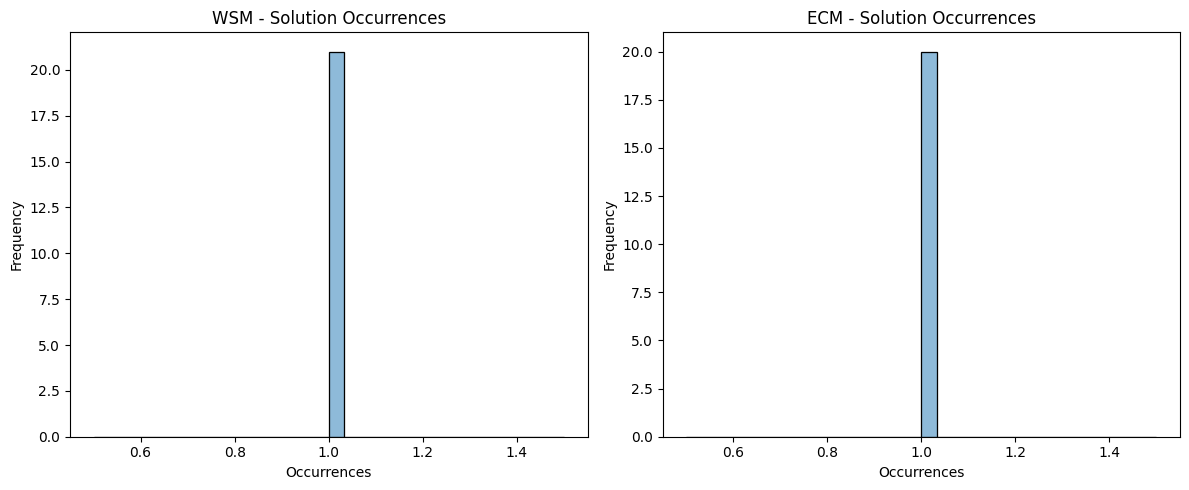

In [23]:
ER.plot_results()

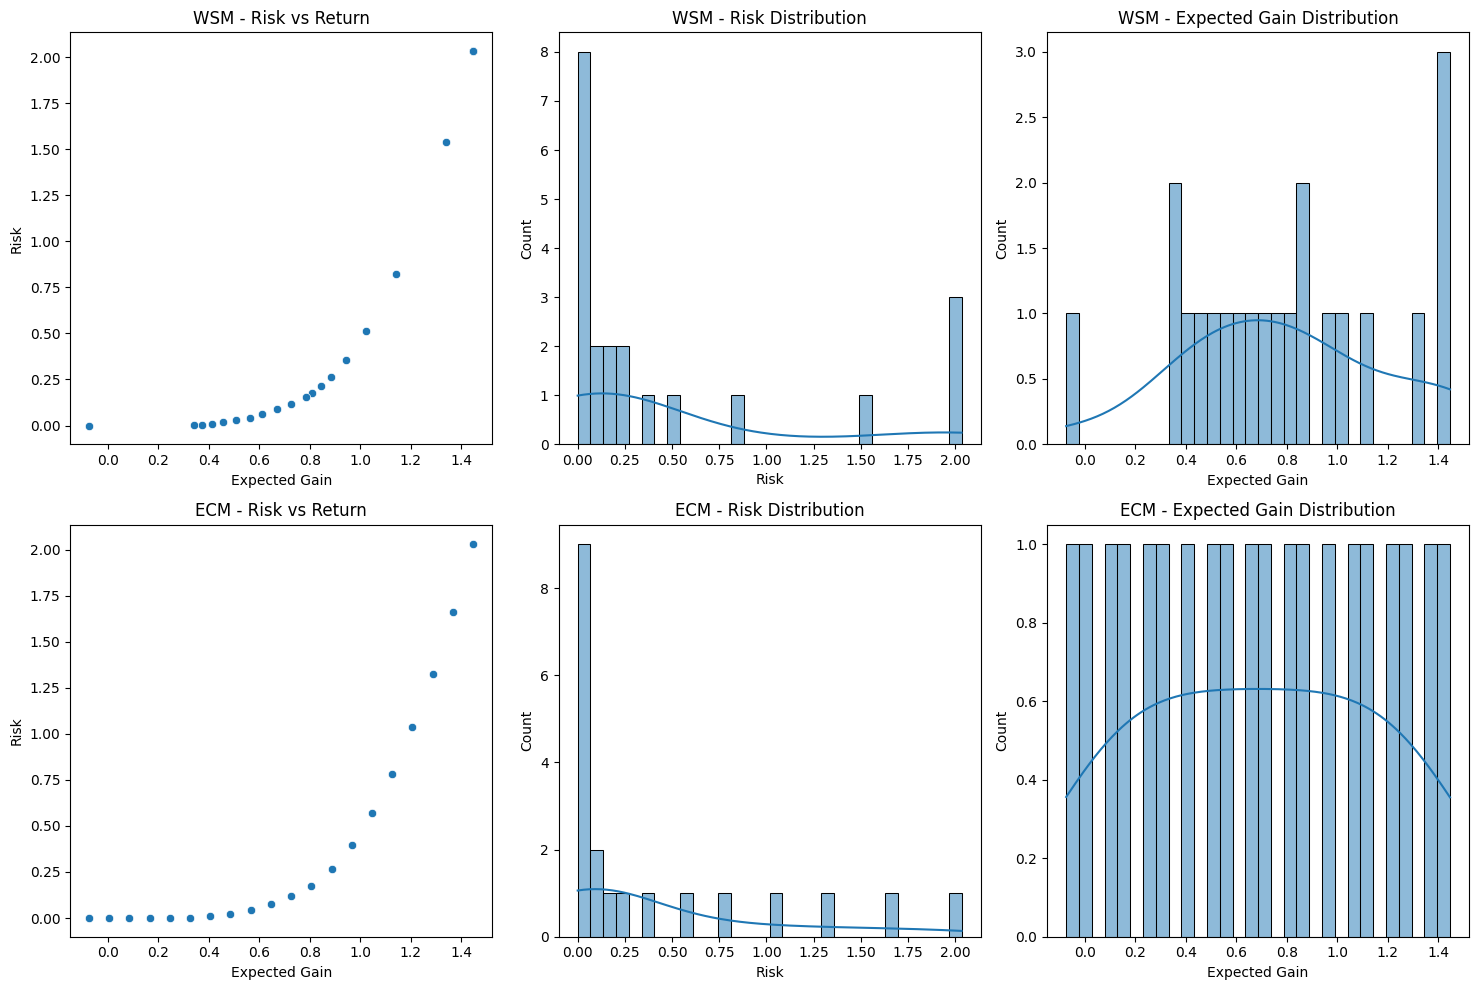

In [24]:
ER.plot_risk_return_distribution()

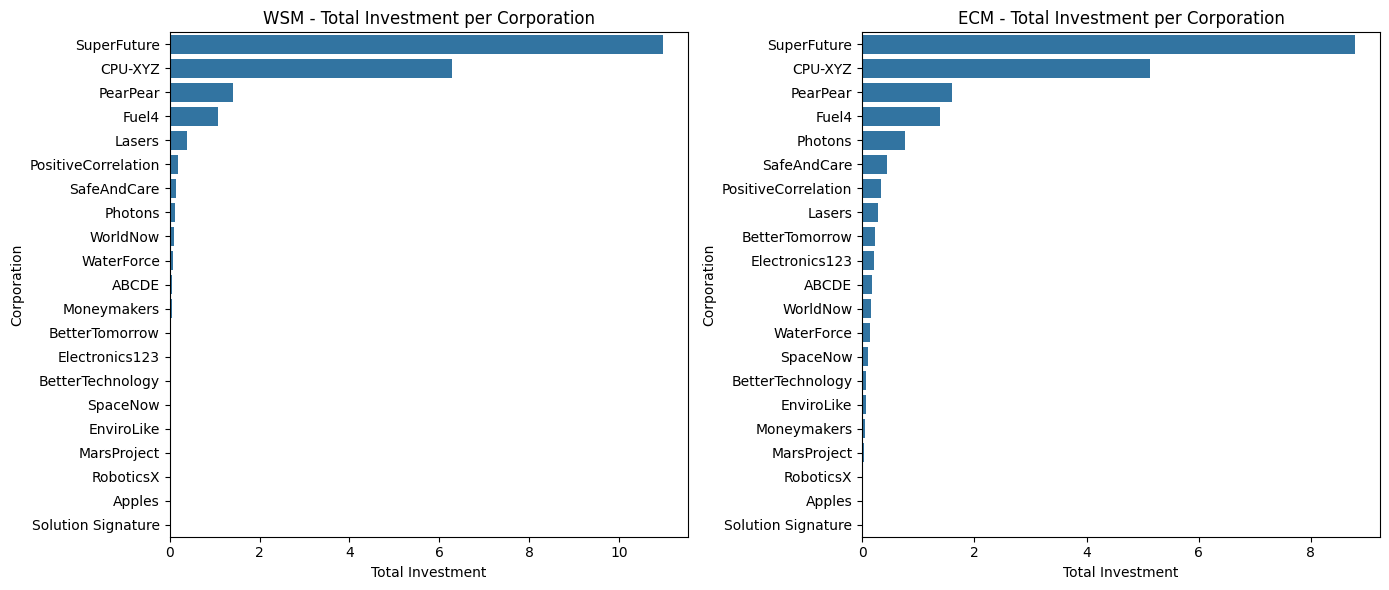

In [25]:
ER.plot_top_corporations()

### 2 to 32 Thresholds/Steps Experiments

In [26]:
thresholds = [2, 4, 8, 12, 16, 20, 32]
steps = [1/2, 1/4, 1/8, 1/16, 1/20, 1/32]

ER = ExperimentRunner(solver=solver)
ER.run_ECM(thresholds)
ER.run_WSM(steps)

Running for threshold=-0.07435369612196875
     pcost       dcost       gap    pres   dres
 0:  1.7397e-03 -2.1859e+01  2e+01  4e-15  5e+00
 1:  1.4299e-03 -5.0194e-01  5e-01  1e-16  1e-01
 2:  7.4309e-04 -4.0032e-02  4e-02  2e-16  1e-02
 3:  3.3320e-04 -1.8136e-03  2e-03  2e-16  8e-05
 4:  2.1709e-04 -5.8553e-05  3e-04  1e-16  3e-06
 5:  1.8252e-04  1.4807e-04  3e-05  1e-16  2e-16
 6:  1.7685e-04  1.7542e-04  1e-06  2e-16  2e-16
 7:  1.7640e-04  1.7633e-04  7e-08  1e-16  8e-17
Optimal solution found.
Running for threshold=1.446334054459383
     pcost       dcost       gap    pres   dres
 0:  9.5805e-02 -2.3426e+01  1e+02  2e+00  6e+00
 1:  5.6400e-01 -1.2375e+01  3e+01  3e-01  9e-01
 2:  1.2530e+00 -2.9228e+00  8e+00  9e-02  2e-01
 3:  1.8113e+00  1.3668e+00  1e+00  1e-02  3e-02
 4:  2.0308e+00  2.0255e+00  1e-02  1e-04  4e-04
 5:  2.0334e+00  2.0333e+00  1e-04  1e-06  4e-06
 6:  2.0334e+00  2.0334e+00  2e-06  2e-08  5e-08
 7:  2.0334e+00  2.0334e+00  7e-08  2e-10  5e-10
Optimal solut

In [27]:
top_ecm, top_wsm = ER.summarize()
top_wsm

,Solution Signature,Frequency,Method
0,"(0.9999999771136435, 3.987643260182986e-10, 1....",6,WSM
1,"(0.5375465632007328, 6.30585400878703e-10, 1.4...",6,WSM
2,"(9.282603772827428e-06, 7.232046042360639e-06,...",6,WSM
3,"(0.7036206585235021, 5.5514575497956324e-09, 1...",5,WSM
4,"(0.32379256222086333, 1.3951633154652985e-08, ...",5,WSM
5,"(0.999995296409085, 1.1647191888893756e-09, 1....",3,WSM
6,"(0.5929071566344621, 1.191788281117265e-10, 4....",3,WSM
7,"(0.45680439620543745, 2.119135828457556e-10, 1...",3,WSM
8,"(0.10878903673969272, 1.1099994172090725e-09, ...",3,WSM
9,"(0.9999999517707684, 5.635613623176975e-10, 2....",2,WSM


In [28]:
top_ecm

,Solution Signature,Frequency,Method
0,"(5.206725885086166e-07, 4.348897571917353e-06,...",7,ECM
1,"(0.9999997318033282, 2.782222648137848e-10, 5....",7,ECM
2,"(0.18324458501851731, 4.932534083978872e-10, 3...",2,ECM
3,"(0.6464016563855417, 2.8559168702094753e-09, 3...",2,ECM
4,"(6.84786592773914e-09, 3.1555685060445822e-09,...",1,ECM
5,"(0.04756381976984514, 7.706610904382163e-11, 9...",1,ECM
6,"(0.42381014146243307, 1.70887858943574e-09, 1....",1,ECM
7,"(0.5453736549605779, 4.391966049787068e-11, 5....",1,ECM
8,"(0.696915676082148, 6.685304336631495e-10, 1.2...",1,ECM
9,"(0.848457706360534, 3.146813569912462e-11, 1.8...",1,ECM


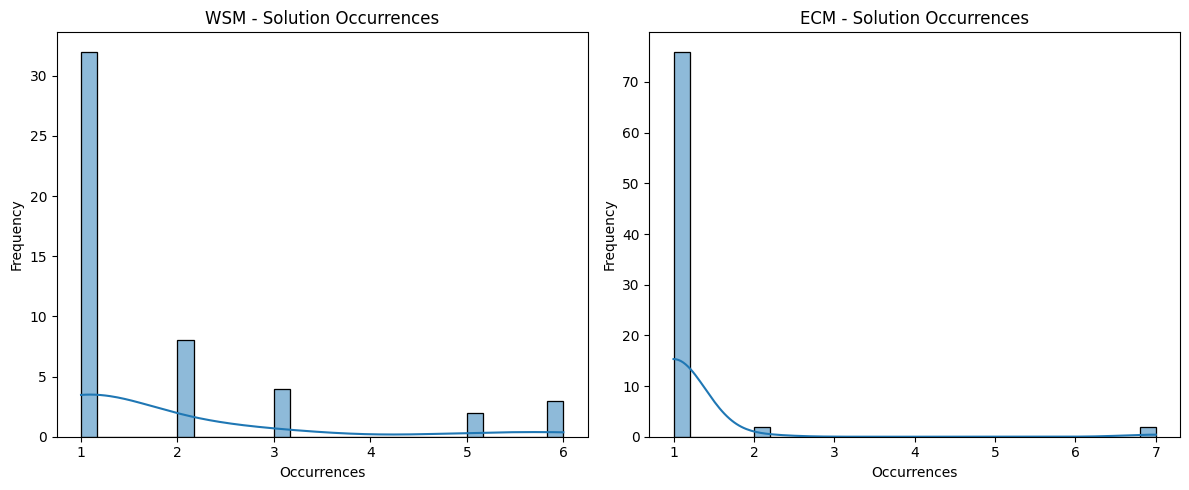

In [29]:
ER.plot_results()

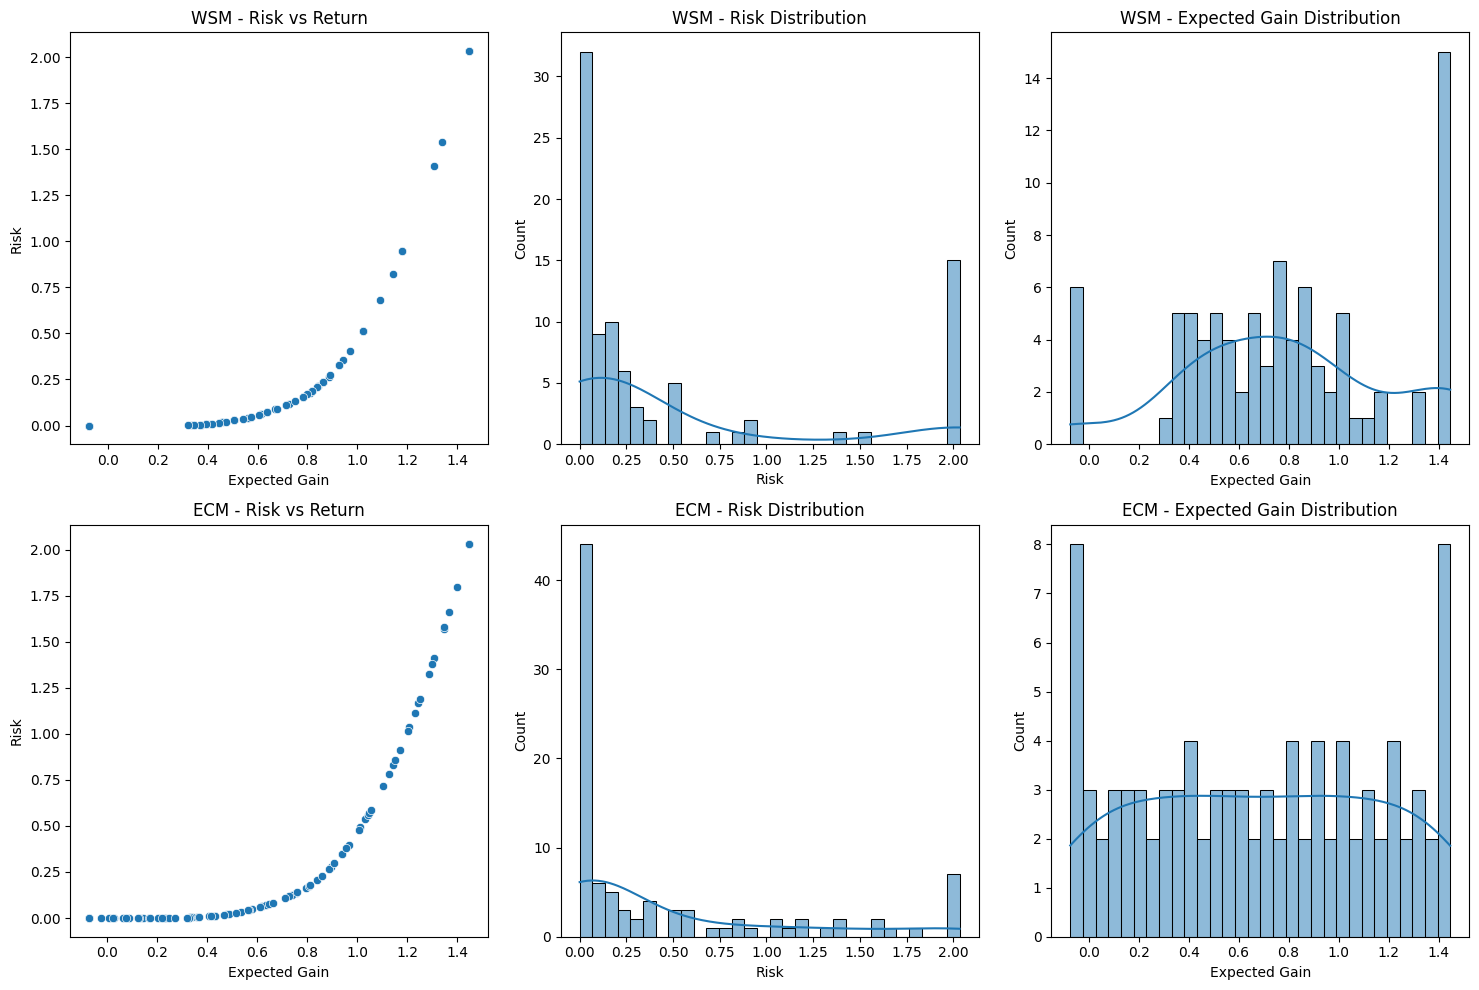

In [30]:
ER.plot_risk_return_distribution()

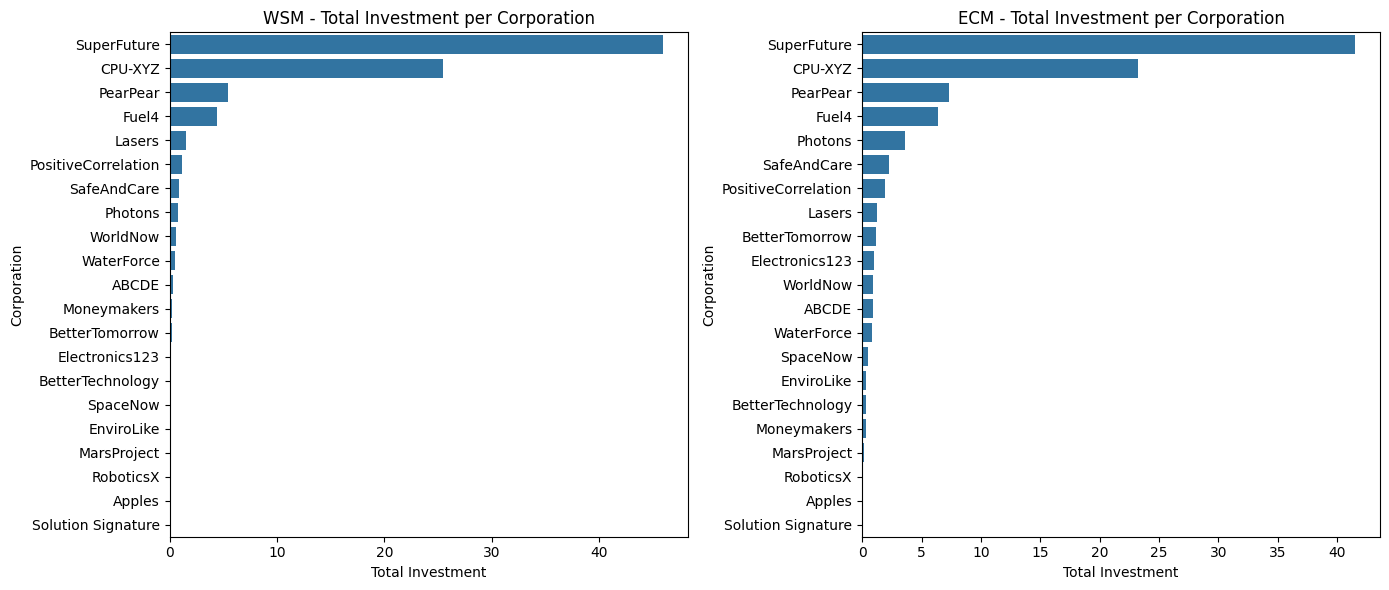

In [31]:
ER.plot_top_corporations()

### 2 to 256 Thresholds/Steps Experiments

In [32]:
thresholds = [2, 4, 8, 12, 16, 20, 32, 64, 128, 256]
steps = [1/2, 1/4, 1/8, 1/16, 1/20, 1/32, 1/64, 1/128, 1/256]

ER = ExperimentRunner(solver=solver)
ER.run_ECM(thresholds)
ER.run_WSM(steps)

Running for threshold=-0.07435369612196875
     pcost       dcost       gap    pres   dres
 0:  1.7397e-03 -2.1859e+01  2e+01  4e-15  5e+00
 1:  1.4299e-03 -5.0194e-01  5e-01  1e-16  1e-01
 2:  7.4309e-04 -4.0032e-02  4e-02  2e-16  1e-02
 3:  3.3320e-04 -1.8136e-03  2e-03  2e-16  8e-05
 4:  2.1709e-04 -5.8553e-05  3e-04  1e-16  3e-06
 5:  1.8252e-04  1.4807e-04  3e-05  1e-16  2e-16
 6:  1.7685e-04  1.7542e-04  1e-06  2e-16  2e-16
 7:  1.7640e-04  1.7633e-04  7e-08  1e-16  8e-17
Optimal solution found.
Running for threshold=1.446334054459383
     pcost       dcost       gap    pres   dres
 0:  9.5805e-02 -2.3426e+01  1e+02  2e+00  6e+00
 1:  5.6400e-01 -1.2375e+01  3e+01  3e-01  9e-01
 2:  1.2530e+00 -2.9228e+00  8e+00  9e-02  2e-01
 3:  1.8113e+00  1.3668e+00  1e+00  1e-02  3e-02
 4:  2.0308e+00  2.0255e+00  1e-02  1e-04  4e-04
 5:  2.0334e+00  2.0333e+00  1e-04  1e-06  4e-06
 6:  2.0334e+00  2.0334e+00  2e-06  2e-08  5e-08
 7:  2.0334e+00  2.0334e+00  7e-08  2e-10  5e-10
Optimal solut

In [33]:
top_ecm, top_wsm = ER.summarize()
top_wsm

,Solution Signature,Frequency,Method
0,"(0.5375465632007328, 6.30585400878703e-10, 1.4...",9,WSM
1,"(9.282603772827428e-06, 7.232046042360639e-06,...",9,WSM
2,"(0.9999999771136435, 3.987643260182986e-10, 1....",9,WSM
3,"(0.7036206585235021, 5.5514575497956324e-09, 1...",8,WSM
4,"(0.32379256222086333, 1.3951633154652985e-08, ...",8,WSM
5,"(0.5929071566344621, 1.191788281117265e-10, 4....",6,WSM
6,"(0.999995296409085, 1.1647191888893756e-09, 1....",6,WSM
7,"(0.45680439620543745, 2.119135828457556e-10, 1...",6,WSM
8,"(0.10878903673969272, 1.1099994172090725e-09, ...",6,WSM
9,"(0.4220747603460263, 7.070040323685822e-10, 7....",5,WSM


In [34]:
top_ecm

,Solution Signature,Frequency,Method
0,"(0.9999997318033282, 2.782222648137848e-10, 5....",10,ECM
1,"(5.206725885086166e-07, 4.348897571917353e-06,...",10,ECM
2,"(0.18324458501851731, 4.932534083978872e-10, 3...",4,ECM
3,"(0.6464016563855417, 2.8559168702094753e-09, 3...",4,ECM
4,"(0.4543761961783789, 8.101677588650045e-11, 7....",2,ECM
5,"(0.5102471442351839, 2.852371213920266e-09, 2....",2,ECM
6,"(0.5756820584447185, 4.857499673317301e-10, 1....",2,ECM
7,"(0.7171212813193161, 3.9268119997322375e-10, 8...",2,ECM
8,"(0.7878408959937928, 1.2347101955214395e-10, 3...",2,ECM
9,"(0.8585605065670949, -7.371781692735489e-12, 2...",2,ECM


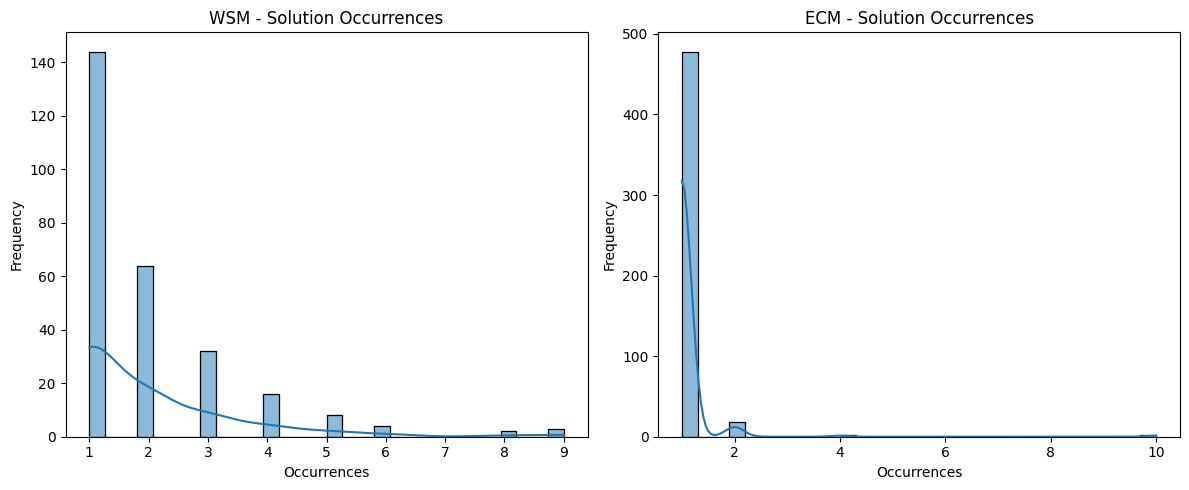

In [35]:
ER.plot_results()

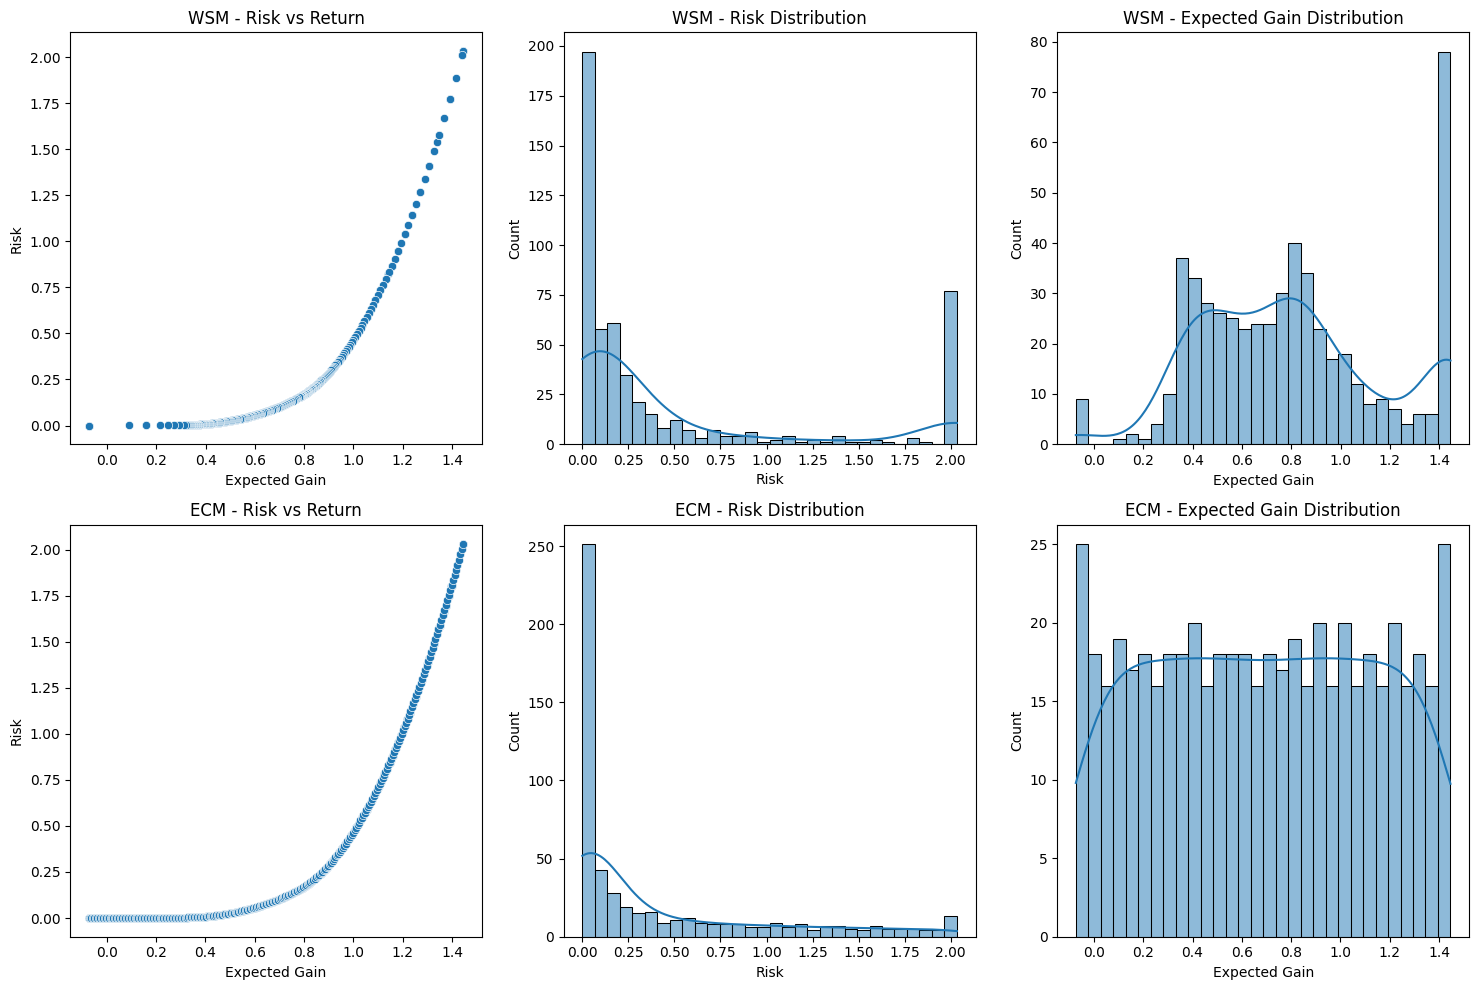

In [36]:
ER.plot_risk_return_distribution()

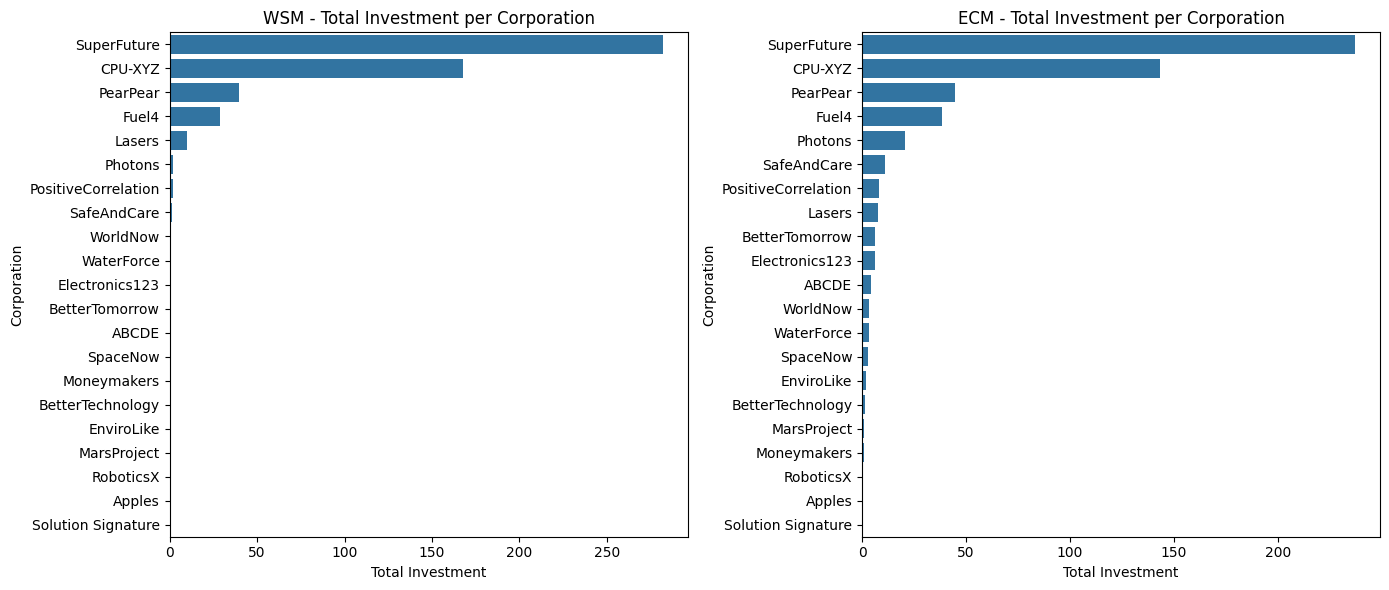

In [37]:
ER.plot_top_corporations()

In [38]:
ECM_results = ER.results_ECM
ECM_results_filtered = ECM_results[ECM_results["Expected Gain"] > 0]
ECM_results_sorted = ECM_results_filtered.sort_values(by="Risk", ascending=True)
ECM_results_sorted.drop(columns=["Solution Signature"], inplace=True)

ECM_results_sorted = ECM_results_sorted.head(40)
ECM_results_sorted

,Expected Gain,Risk,SuperFuture,Apples,WorldNow,Electronics123,Photons,SpaceNow,PearPear,PositiveCorrelation,...,Moneymakers,Fuel4,MarsProject,CPU-XYZ,RoboticsX,Lasers,WaterForce,SafeAndCare,BetterTomorrow,Sanity Check
299,0.003172,0.000233,3.602114e-06,3.826397e-07,5.480728e-02,0.044445,0.183127,0.016889,0.041735,0.104777,...,3.579991e-03,0.127719,0.010988,0.076048,1.810416e-05,0.000096,0.057061,0.138127,0.048432,1.0
43,0.005683,0.000236,3.822532e-08,5.551631e-09,5.392633e-02,0.044916,0.183859,0.016638,0.043640,0.102649,...,1.787290e-03,0.128906,0.011160,0.077311,2.093996e-07,0.000001,0.056503,0.137923,0.048943,1.0
300,0.009135,0.000241,4.332405e-08,7.377079e-09,5.195905e-02,0.045436,0.184823,0.016774,0.046425,0.099881,...,7.129960e-04,0.130084,0.011328,0.079313,2.101284e-07,0.000001,0.054710,0.137136,0.049661,1.0
165,0.009464,0.000241,4.316469e-08,7.349951e-09,5.175435e-02,0.045484,0.184913,0.016797,0.046694,0.099623,...,6.405628e-04,0.130186,0.011343,0.079509,2.067984e-07,0.000001,0.054518,0.137052,0.049731,1.0
301,0.015099,0.000250,3.699715e-08,4.803596e-09,4.785527e-02,0.046239,0.186418,0.017432,0.051402,0.095293,...,6.750178e-05,0.131696,0.011555,0.083004,1.332832e-07,0.000001,0.050741,0.135406,0.050951,1.0
302,0.021062,0.000259,4.122296e-08,5.047024e-09,4.340998e-02,0.046994,0.187980,0.018296,0.056459,0.090799,...,7.747409e-06,0.133104,0.011752,0.086808,1.074738e-07,0.000002,0.046351,0.133495,0.052264,1.0
166,0.021438,0.000259,4.100513e-08,5.019109e-09,4.312823e-02,0.047041,0.188078,0.018352,0.056778,0.090516,...,6.937288e-06,0.133191,0.011765,0.087049,1.051327e-07,0.000002,0.046072,0.133373,0.052347,1.0
98,0.022198,0.000260,4.048083e-08,4.952250e-09,4.255784e-02,0.047137,0.188276,0.018464,0.057424,0.089944,...,5.617060e-06,0.133369,0.011789,0.087535,1.004528e-07,0.000002,0.045508,0.133128,0.052514,1.0
64,0.023755,0.000263,3.911755e-08,4.777210e-09,4.138892e-02,0.047333,0.188683,0.018694,0.058746,0.088772,...,3.827953e-06,0.133731,0.011840,0.088531,9.119740e-08,0.000002,0.044351,0.132625,0.052858,1.0
27,0.027026,0.000268,1.456357e-07,1.363310e-08,3.893326e-02,0.047744,0.189539,0.019179,0.061524,0.086311,...,4.419079e-06,0.134492,0.011946,0.090624,2.744334e-07,0.000006,0.041919,0.131564,0.053578,1.0


In [42]:
def save_solution(df, index, value, filename="solution.txt"):
    if index not in df.index:
        print(f"Error: Index {index} not found in DataFrame.")
        return
    
    row = df.loc[index]
    expected_total_return = (1.0 + row["Expected Gain"]) * value
    expected_total_risk = row["Risk"]
    weights = [row[company] for company in ORDER]
    solution_line = f"{expected_total_return:.10f} {expected_total_risk:.10f} " + " ".join(f"{w:.10f}" for w in weights)
    with open(filename, "w") as file:
        file.write(solution_line)
    print(f"Solution saved successfully in {filename} with a produced weight sum: {sum(weights)}")

save_solution(ECM_results_sorted, 299, 100, filename="stage_1_safest.txt")
save_solution(ECM_results_sorted, 99, 100, filename="stage_1_mid.txt")
save_solution(ECM_results_sorted, 174, 100, filename="stage_1_risky.txt")

Solution saved successfully in stage_1_safest.txt with a produced weight sum: 1.0
Solution saved successfully in stage_1_mid.txt with a produced weight sum: 1.0
Solution saved successfully in stage_1_risky.txt with a produced weight sum: 0.9999999999999997
